Warning message:
“package ‘rrvgo’ was built under R version 4.3.3”


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”



    down trans_up       up 
     717      513      910 

circlize version 0.4.17
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




[1] "#A6CEE3" "#1F78B4" "#B2DF8A" "#33A02C" "#FB9A99"

Warning message:
“Since you have set `order`, you should better set `grid.col` as a named
vector where sector names are the vector names, or else the color will
be wrongly assigned.”
Warning message:
“Since you have set `group`, you should better set `grid.col` as a named
vector where sector names are the vector names, or else the color will
be wrongly assigned.”
Note: 1 point is out of plotting region in sector 'EN_down', track '1'.

Note: 1 point is out of plotting region in sector 'EN_down', track '1'.

Note: 7 points are out of plotting region in sector 'EN_down', track
'1'.

Note: 1 point is out of plotting region in sector 'EN_up', track '1'.

Note: 1 point is out of plotting region in sector 'EN_up', track '1'.

Note: 5 points are out of plotting region in sector 'EN_up', track '1'.

Note: 1 point is out of plotting region in sector 'EN_trans_up', track
'1'.

Note: 1 point is out of plotting region in sector 'EN_trans_up', track
'1'.

Note: 11 points are out of plotting region i

pdf 
  2

null device 
          1

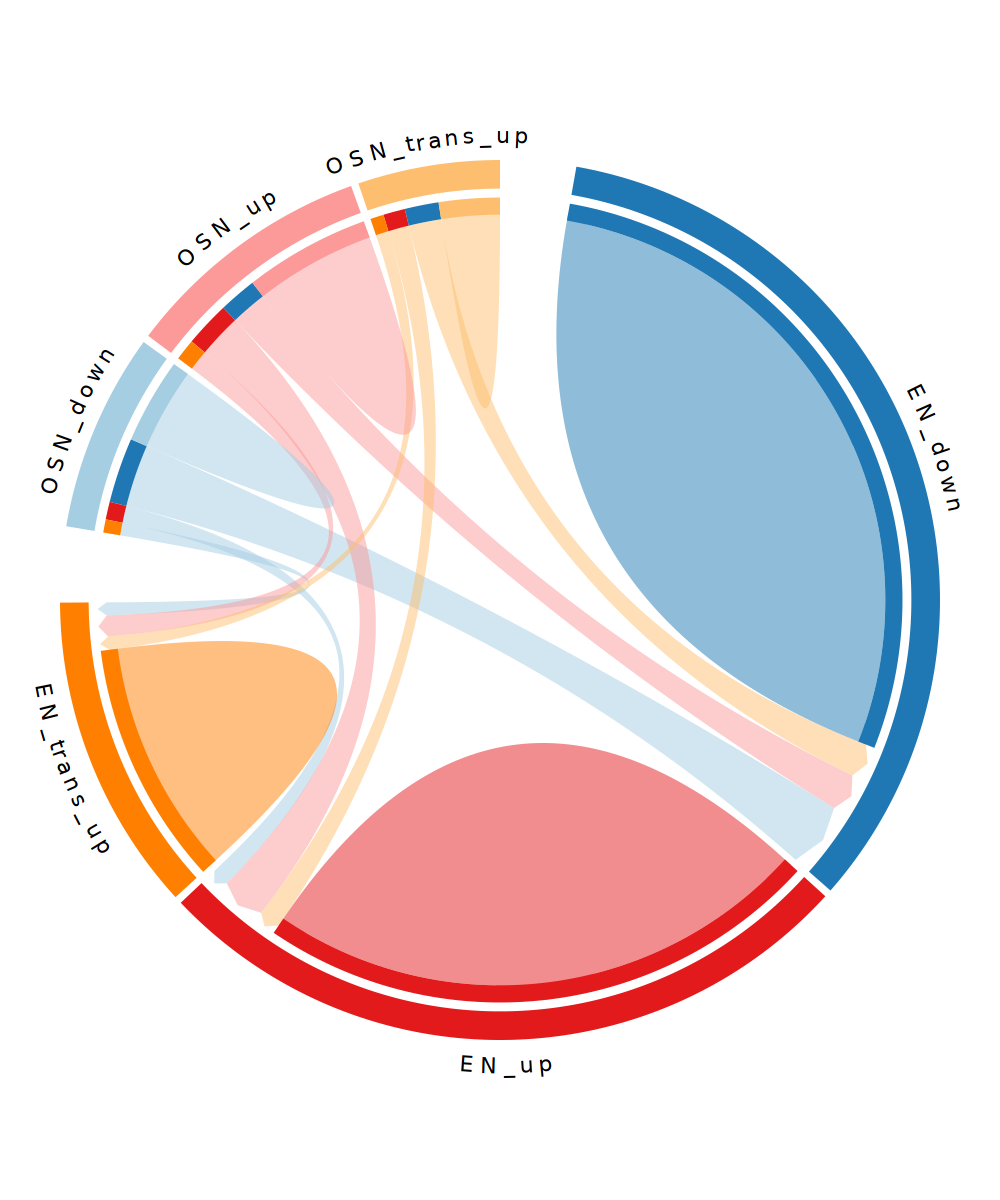

In [1]:
library(stringr)
library(gprofiler2)
library(rrvgo)
library(ggplot2)

options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 100)


dev_files <- list.files('/sc/arion/projects/roussp01a/liting/Olf/data/lister_devDEG/', '.txt')
dev_gs <- c()
for(fl in dev_files){
  dev_g <- read.table(paste0('/sc/arion/projects/roussp01a/liting/Olf/data/lister_devDEG/',fl),header = T)
  cell_type <- gsub('\\.txt|-','',fl)
  dev_g$celltype <- cell_type
  dev_gs <- rbind(dev_g,dev_gs)
}

dev_gs <- subset(dev_gs, !grepl('^MT|^LINC|^MIR|^RP',gene_name ) & celltype=="L23_CUX2")

#num_devG_trend <- lapply( split(dev_gs,dev_gs$trend_class), function(x) table(x$gene_name))

# consensus DEGs across cell types in each trend
down_brain <- subset(dev_gs, trend_class=='down')[,"gene_name"]
up_brain <- subset(dev_gs, trend_class=='up')[,"gene_name"]
#trans_down_brain <- subset(dev_gs, trend_class=='trans_down')[,"gene_name"]
trans_up_brain <- subset(dev_gs, trend_class=='trans_up')[,"gene_name"]

DEG_trend_Brain <- list(down=down_brain, 
                        up=up_brain, 
                        #trans_down=trans_down_brain, 
                        trans_up=trans_up_brain)


# OLF devDEGs
#load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k6.RData')
load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph_entgoldstein.RData')
table(DEG_trend_Olf$trend_class)

# format DEG_overlap_gene[trend_Olf][trend_Brain]
DEG_overlap_gene <- list()
for (t1 in c('down','up','trans_up')){
  DEG_overlap_gene[[t1]] <- lapply(DEG_trend_Brain, function(x) intersect( x, DEG_trend_Olf$gene[DEG_trend_Olf$trend_class==t1]) )
}


n_DEG_overlap_gene <- as.data.frame(unlist(lapply(DEG_overlap_gene, function(x) lapply(x, length) )))
n_DEG_overlap_gene <- cbind(n_DEG_overlap_gene, str_split( rownames(n_DEG_overlap_gene),'\\.',simplify = T))
colnames(n_DEG_overlap_gene) <- c('n','Olf_trend','Brain_trend')
n_DEG_overlap_gene$Olf_trend <- paste0('OSN_',n_DEG_overlap_gene$Olf_trend)
n_DEG_overlap_gene$Brain_trend <- paste0('EN_',n_DEG_overlap_gene$Brain_trend)

unique_olf <- table((subset(DEG_trend_Olf,!gene%in% unlist(DEG_trend_Brain)))$trend_class)
unique_brain <- sapply(DEG_trend_Brain, function(x) length(setdiff(x, DEG_trend_Olf$gene)))

uniq_genes <- as.data.frame(rbind(
  cbind(
    unique_olf,
    paste0('OSN_', names(unique_olf) ),
    paste0('OSN_',  names(unique_olf) )
  ),
  cbind(
    unique_brain,
    paste0('EN_', names(unique_brain) ) ,
    paste0('EN_', names(unique_brain) ) 
  )))
colnames(uniq_genes) <- c('n','Olf_trend','Brain_trend')

n_cicle_DE <- rbind(n_DEG_overlap_gene, uniq_genes)

n_cicle_DE$n <- as.numeric(n_cicle_DE$n)

# ggplot(n_DEG_overlap_gene, aes(x=Olf_trend,y=Brain_trend))+
#   geom_tile(aes(fill = n))
library(circlize)

library(RColorBrewer)
brewer.pal(n = 5, name = "Paired")


col_fun = colorRamp2(seq(1,300,50), rev(brewer.pal(6, "RdBu")))
#col <- ifelse(n_cicle_DE$Olf_trend!=n_cicle_DE$Brain_trend,col_fun(n_cicle_DE$n), "#FFFFFF00")

library(RColorBrewer)
circos.par(start.degree = 80)
nm = c(paste0(c("OSN_"), c('down','up','trans_up')), paste0(c("EN_"), c('down','up','trans_up')))
group = structure(c(rep('OSN_',3),rep('EN_',3)), names = nm)

chordDiagram(n_cicle_DE[,c(2,3,1)], self.link = 1, 
             order = nm,
             grid.col = brewer.pal(n = 8, name = "Paired")[c(1,5,7,2,6,8)],
             #col=col, 
             annotationTrack = c("grid"),
             annotationTrackHeight = mm_h(5) ,
             diffHeight = mm_h(3), target.prop.height = mm_h(5),
             directional = 1, direction.type = c("diffHeight", "arrows"), 
             link.arr.type = "big.arrow",
             group = group,
             big.gap = 10)

for(si in get.all.sector.index()) {
  xlim = get.cell.meta.data("xlim", sector.index = si, track.index = 1)
  ylim = get.cell.meta.data("ylim", sector.index = si, track.index = 1)
  circos.text(mean(xlim), 2, si, sector.index = si, track.index = 1, cex = 1.3,
              facing = "bending.inside", niceFacing = TRUE, col = "black")
}
circos.clear()
#draw(x = unit(0.82, "npc"), y = unit(0.6, "npc"),just="left",Legend(col_fun = col_fun, title = "Number of links"))
dev.print(pdf, file='./figures/NC/devdeg_overlap.pdf',width=6.6, height=7)
dev.off()



In [2]:
n_DEG_overlap_gene
221/602
39/389
152/785

#602      389      785 
#DEG_trend_Olf['TCF4',]

,n,Olf_trend,Brain_trend
,<int>,<chr>,<chr>
down.down,221,OSN_down,EN_down
down.up,58,OSN_down,EN_up
down.trans_up,32,OSN_down,EN_trans_up
up.down,133,OSN_up,EN_down
up.up,152,OSN_up,EN_up
up.trans_up,83,OSN_up,EN_trans_up
trans_up.down,116,OSN_trans_up,EN_down
trans_up.up,56,OSN_trans_up,EN_up
trans_up.trans_up,39,OSN_trans_up,EN_trans_up


[1] 0.3671096

[1] 0.1002571

[1] 0.1936306

In [2]:
load('./data/custom_olfbg.RData')
load('./data/lister_brain_bg.RData')
overlap_bg <- intersect(brain_bg,custom_olfbg )


Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“EOF within quoted string”
Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“number of items read is not a multiple of the number of columns”


pdf 
  2

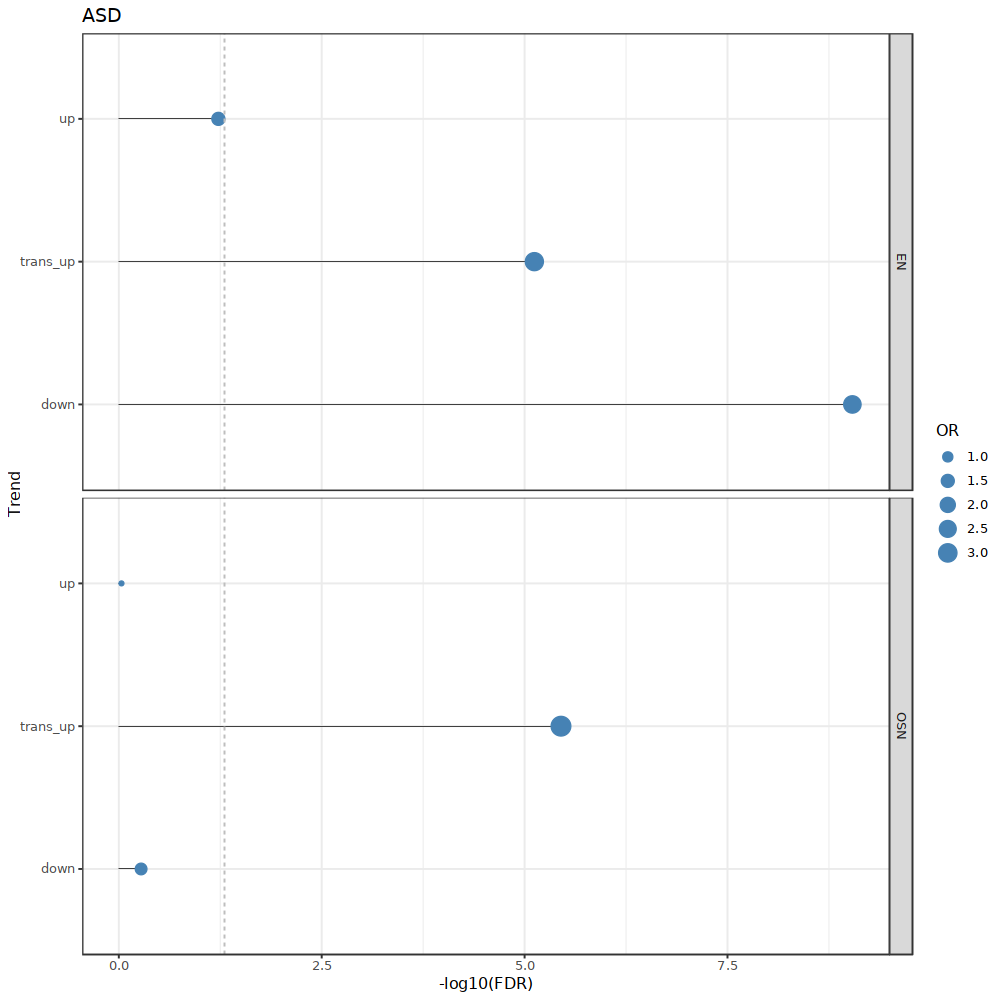

In [47]:
SFARI <- read.table('./data/SFARI.txt', sep='\t',header = T)
SFARI <- subset(SFARI, gene.score==1|syndromic==1)
ASD <- SFARI$gene.symbol

fisher <- function(Disease, DEG, BG){
    Disease <- intersect(Disease, BG)
    aa <- length(intersect(Disease, DEG))
    bb <- length(setdiff(Disease, DEG))
    cc <- length(setdiff(DEG, Disease))
    dd <- length(setdiff(BG, c(Disease, DEG)))
    
    test <- fisher.test(matrix(c(aa,bb,cc,dd),2),alternative='greater')

    return(paste(test$p.value, test$estimate, sep='~'))
}

enrich_D_EN <- c()

for (trend in names(DEG_trend_Brain)){
        pv <- fisher(Disease=ASD,
               DEG = DEG_trend_Brain[[trend]], 
               BG= brain_bg)
    enrich_D_EN <- rbind(enrich_D_EN, c(trend, pv, paste(intersect(DEG_trend_Brain[[trend]],ASD),collapse=',') ) )
   
 }
enrich_D_EN <- as.data.frame(enrich_D_EN)
colnames(enrich_D_EN) <- c('trend','p_or','gene')

enrich_D_EN$p <- as.numeric(str_split(enrich_D_EN$p_or,'~',simplify = T)[,1])
enrich_D_EN$OR <- as.numeric(str_split(enrich_D_EN$p_or,'~',simplify = T)[,2])
enrich_D_EN$FDR <- p.adjust(enrich_D_EN$p)

enrich_D_EN$Cell <- 'EN'

enrich_D_osn <- c()

for (trend in unique(DEG_trend_Olf$trend_class)){
        pv <- fisher(Disease=ASD,
               DEG = subset(DEG_trend_Olf,trend_class==trend)[,'gene'], 
               BG= custom_olfbg)
    enrich_D_osn <- rbind(enrich_D_osn, c(trend, pv, paste(intersect(subset(DEG_trend_Olf,trend_class==trend)[,'gene'],
                  ASD),collapse=',') ) )
   
 }
enrich_D_osn <- as.data.frame(enrich_D_osn)
colnames(enrich_D_osn) <- c('trend','p_or','gene')

enrich_D_osn$p <- as.numeric(str_split(enrich_D_osn$p_or,'~',simplify = T)[,1])
enrich_D_osn$OR <- as.numeric(str_split(enrich_D_osn$p_or,'~',simplify = T)[,2])
enrich_D_osn$FDR <- p.adjust(enrich_D_osn$p)

enrich_D_osn$Cell <- 'OSN'

enrich_D <- rbind(enrich_D_EN, enrich_D_osn)
enrich_D$FDR <- p.adjust(enrich_D$p)

ggplot(subset(enrich_D,trend!='trans_down' ), aes (x=trend, y=-log10(FDR),size=OR))+#,color=OR>1
facet_grid(Cell~.,scales = 'free_y')+
geom_segment(aes(x = trend, xend = trend, y = 0, yend = -log10(FDR)), 
              color = "black", size = 0.2)+theme_bw()+
geom_point(color='steelblue')+
labs(y='-log10(FDR)',x='Trend',title='ASD')+coord_flip()+#color='OR > 1'
geom_hline(yintercept=-log10(0.05),  linetype='dashed', col = 'gray')+
scale_color_manual(values =  c('#B8B8B8','#2D81BC'))

dev.print(pdf, file='./figures/NC/SFARI.pdf', width=4, height=3.5)


In [49]:
write.table(subset(enrich_D,trend!='trans_down' )[,c(-2,-3)], file='./data/NC/f4a_asd_or.txt', sep='\t', quote = F)

In [5]:

#save(DEG_overlap_gene, unique_brain, unique_olf, file='./data/degs.RData')

### enriched pathway of different gene sets

In [4]:
# overlappped gene pathway enrichment

get_bp <- function(olf_trend, brain_trend){
  enrr <- c()
  query_gene <- DEG_overlap_gene[[olf_trend]][[brain_trend]]
  
  if (length(query_gene)>20){
    enriched <- gost(query_gene,source=c('GO:BP'),correction_method = "fdr",custom_bg = overlap_bg,user_threshold=0.1,significant=F)
    enrr <- enriched$result %>%subset(term_size < 2000)
    
    enrr$olf_trend <- olf_trend
    enrr$brain_trend <- brain_trend
    
  }
  return(enrr) 
}

gobps_devDEG <- c()
for (olf_trend in c('up','down','trans_up','trans_down')){
  for(brain_trend in c('up','down','trans_up','trans_down')){
    gobp_devDEG <- get_bp(olf_trend, brain_trend)
    gobps_devDEG <- rbind(gobps_devDEG, gobp_devDEG)
  }
}

# brain unique gene
unique_brain <- sapply(DEG_trend_Brain, function(x) setdiff(x, DEG_trend_Olf$gene))

unique_brain_gobp <- lapply(unique_brain, function(x) {df <-    gost(x, source=c('GO:BP'),custom_bg = brain_bg,  
                                                                     correction_method = "fdr",user_threshold=0.1,
                                                                    #evcodes=T,
                                                                     significant=F)$result %>%subset(term_size < 2000)  } )
                       
unique_brain_gobps <- do.call(rbind,unique_brain_gobp)
unique_brain_gobps$brain_trend <- str_split(rownames(unique_brain_gobps),pattern = '\\.',simplify = T)[,1]

# olf unique gene
unique_olf <- subset(DEG_trend_Olf,!gene%in% unlist(DEG_trend_Brain))
unique_olf <- split(unique_olf$gene,unique_olf$trend_class)
unique_olf_gobp <- lapply(unique_olf, function(x) {df <-    gost(x, source=c('GO:BP'), custom_bg = custom_olfbg, 
                                                                 #evcodes=T,
                                                                 correction_method = "fdr",user_threshold=0.1,significant=F)$result %>%subset(term_size < 2000)  } )

unique_olf_gobps <- do.call(rbind,unique_olf_gobp)
unique_olf_gobps$olf_trend <- str_split(rownames(unique_olf_gobps),pattern = '\\.',simplify = T)[,1]


Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope i

In [5]:
# input for magma
brain_unique_gene <- as.data.frame(unlist(unique_brain))
brain_unique_gene$cat <- paste0('EN',gsub('\\d+','',rownames(brain_unique_gene)))
colnames(brain_unique_gene) <- c('gene','cat')

olf_unique_gene <- as.data.frame(unlist(unique_olf))
olf_unique_gene$cat <- paste0('OSN',gsub('\\d+','',rownames(olf_unique_gene)))
colnames(olf_unique_gene) <- c('gene','cat')

overlap_gene <- as.data.frame(unlist(DEG_overlap_gene))
overlap_gene$cat <- paste0(gsub('\\d+','',rownames(overlap_gene)))
colnames(overlap_gene) <- c('gene','cat')

deggenes <- rbind(brain_unique_gene, olf_unique_gene, overlap_gene)
#save(deggenes, file='./data/deggenes1.RData')
#deggenes <- subset(deggenes, cat%in%names(table(deggenes$cat))[which(table(deggenes$cat)> 30)])
deggenes$catmerge <- ifelse(grepl('\\.',deggenes$cat ),str_split(deggenes$cat,pattern = '\\.',simplify = T)[,1], deggenes$cat)

save(deggenes, file='./data/deggenes_nc.RData')
#split(deggenes$gene,deggenes$cat)
    

In [1]:
load('./data/deggenes_nc.RData')

Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“EOF within quoted string”
Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“number of items read is not a multiple of the number of columns”


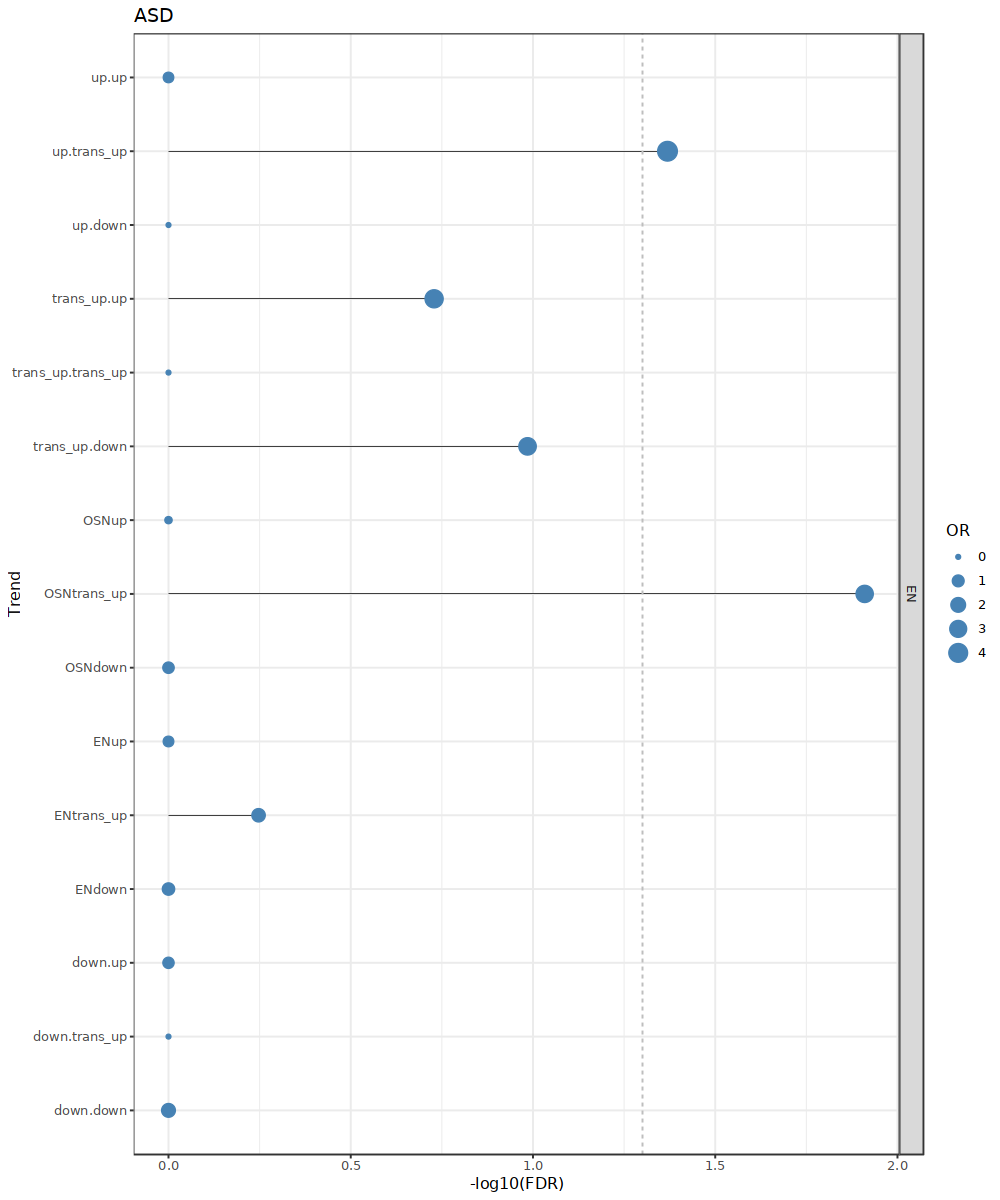

In [6]:
library(stringr)
library(ggplot2)
SFARI <- read.table('./data/SFARI.txt', sep='\t',header = T)
SFARI <- subset(SFARI, gene.score==1|syndromic==1)
ASD <- SFARI$gene.symbol

fisher <- function(Disease, DEG, BG){
    Disease <- intersect(Disease, BG)
    aa <- length(intersect(Disease, DEG))
    bb <- length(setdiff(Disease, DEG))
    cc <- length(setdiff(DEG, Disease))
    dd <- length(setdiff(BG, c(Disease, DEG)))
    
    test <- fisher.test(matrix(c(aa,bb,cc,dd),2),alternative='greater')

    return(paste(test$p.value, test$estimate, sep='~'))
}

enrich_D_EN <- c()

for (trend in unique(deggenes$cat)){
        pv <- fisher(Disease=ASD,
               DEG = subset(deggenes,cat==trend )[,'gene'], 
               BG= overlap_bg)
    enrich_D_EN <- rbind(enrich_D_EN, c(trend, pv, paste(intersect(subset(deggenes,cat==trend )[,'gene'],ASD),collapse=',') ) )
   
 }
enrich_D_EN <- as.data.frame(enrich_D_EN)
colnames(enrich_D_EN) <- c('trend','p_or','gene')

enrich_D_EN$p <- as.numeric(str_split(enrich_D_EN$p_or,'~',simplify = T)[,1])
enrich_D_EN$OR <- as.numeric(str_split(enrich_D_EN$p_or,'~',simplify = T)[,2])
enrich_D_EN$FDR <- p.adjust(enrich_D_EN$p)

enrich_D_EN$Cell <- 'EN'
enrich_D_EN$FDR <- p.adjust(enrich_D_EN$p)

ggplot(subset(enrich_D_EN,trend!='trans_down' ), aes (x=trend, y=-log10(FDR),size=OR))+#,color=OR>1
facet_grid(Cell~.,scales = 'free_y')+
geom_segment(aes(x = trend, xend = trend, y = 0, yend = -log10(FDR)), 
              color = "black", size = 0.2)+theme_bw()+
geom_point(color='steelblue')+
labs(y='-log10(FDR)',x='Trend',title='ASD')+coord_flip()+#color='OR > 1'
geom_hline(yintercept=-log10(0.05),  linetype='dashed', col = 'gray')+
scale_color_manual(values =  c('#B8B8B8','#2D81BC'))

#dev.print(pdf, file='./figures/NC/SFARI.pdf', width=4, height=3.5)


### plot enriched gobp

In [10]:
#subset(pp,  trend=='OSN-specific trans_up')

In [7]:
unique_brain_gobps$trend <- paste0("EN-specific " , unique_brain_gobps$brain_trend)
unique_olf_gobps$trend <- paste0("OSN-specific " , unique_olf_gobps$olf_trend)
gobps_devDEG$trend <- ifelse(gobps_devDEG$olf_trend==gobps_devDEG$brain_trend,
                             paste0('Shared ', gobps_devDEG$olf_trend),
                             paste0("OSN-",gobps_devDEG$olf_trend,' ~ ','EN-', gobps_devDEG$brain_trend))

p1 <- unique_brain_gobps[,c('p_value','term_size','query_size','intersection_size','term_name','term_id','trend')]
p2 <- unique_olf_gobps[,c('p_value','term_size','query_size','intersection_size','term_name','term_id','trend')]
p3 <- gobps_devDEG[,c('p_value','term_size','query_size','intersection_size','term_name','term_id','trend')]

pp <- rbind(p1,p2,p3)

In [8]:
library(dplyr)

sig_pp <- subset(pp, p_value < 0.05)#%>%group_by(trend)%>%top_n(20, -p_value)
sig_pp <- sig_pp[,c(7,6,5,2:4,1)]
colnames(sig_pp)[7] <- 'FDR'
write.table(sig_pp, file='./figures/NC/De_overlap_GO_all.txt',row.names = F, sep='\t')


Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




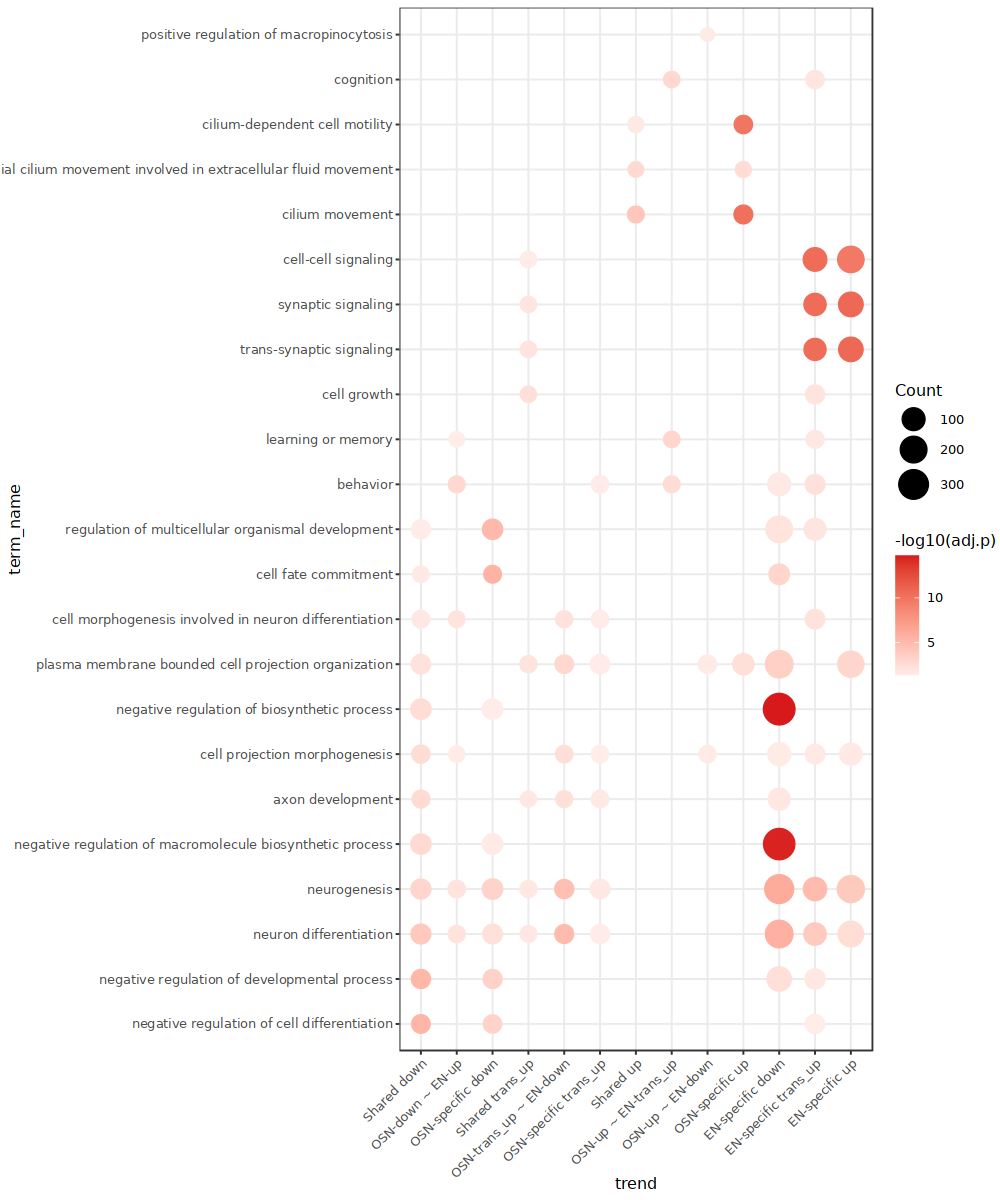

In [9]:
# pp_sig <- subset(pp, p_value < 0.05)
# #pp_sig$p_value  <- pp_sig$p_value+c(1:nrow(pp_sig))/10000000
# pp_sig <- pp_sig%>%group_by(trend)%>%top_n(5, -p_value)


pp$p_value  <- pp$p_value+c(1:nrow(pp))/(0.1/min(pp$p_value))
pp_sig <- pp%>%subset(p_value < 0.05)%>%group_by(trend)%>%top_n(2, -p_value)

pp_sig <- subset(pp, term_name%in%pp_sig$term_name)%>%subset(p_value < 0.05)

# order_pattern <- c(
#     'Shared down','OSN-down ~ EN-trans_down','OSN-down ~ EN-up','OSN-down ~ EN-trans_up','OSN-specific down','EN-specific down',
#     'Shared trans_up','OSN-trans_up ~ EN-down','OSN-trans_up ~ EN-trans_down','OSN-trans_up ~ EN-up','OSN-specific trans_up','EN-specific trans_up',
#     'Shared trans_down','OSN-trans_down ~ EN-up','OSN-trans_down ~ EN-trans_up','OSN-specific trans_down','EN-specific trans_down',
#     'Shared up', 'OSN-up ~ EN-trans_up','OSN-up ~ EN-down', 'OSN-up ~ EN-trans_down', 'OSN-specific up','EN-specific up'
#  )

order_pattern <- c(
    'Shared down','OSN-down ~ EN-trans_down','OSN-down ~ EN-up','OSN-down ~ EN-trans_up','OSN-specific down',
    'Shared trans_up','OSN-trans_up ~ EN-down','OSN-trans_up ~ EN-trans_down','OSN-trans_up ~ EN-up','OSN-specific trans_up',
    'Shared trans_down','OSN-trans_down ~ EN-up','OSN-trans_down ~ EN-trans_up','OSN-specific trans_down',
    'Shared up', 'OSN-up ~ EN-trans_up','OSN-up ~ EN-down', 'OSN-up ~ EN-trans_down', 'OSN-specific up',
    'EN-specific down','EN-specific trans_up','EN-specific trans_down','EN-specific up'
 )

pp_sig <- subset(pp_sig, trend!='EN-specific trans_down')

pp_sig$trend <- factor(pp_sig$trend,levels = order_pattern)


pp_sig <- pp_sig[order(pp_sig$trend),]


pp_sig$term_name <- factor(pp_sig$term_name, levels=unique(pp_sig$term_name))


ggplot(pp_sig, aes(x=trend,y=term_name,size=intersection_size,color=-log10(p_value)))+geom_point() +
            scale_size(range = c(4, 10)) +
            labs( size = "Count", color = "-log10(adj.p)") +
            scale_color_gradient2(high="#D7191C", mid="white", low="#2C7BB6", name = "-log10(adj.p)")+theme_bw()+
theme(axis.text.x=element_text(angle=45, hjust=1,vjust=1))

In [10]:
get_bp_enrichr_reducedTerms <- function(go_analysis){
  #go_analysis$GOID <- str_split(go_analysis$Term,'\\(|\\)',simplify = T)[,2]
  simMatrix <- calculateSimMatrix(go_analysis$term_id,
                                  orgdb="org.Hs.eg.db",
                                  ont=c('BP'),
                                  method="Rel")
  
  
  scores <- setNames(-log10(as.numeric(go_analysis$p_value)), go_analysis$term_id)
  reducedTerms <- reduceSimMatrix(simMatrix,
                                  scores,
                                  orgdb="org.Hs.eg.db")

  return(reducedTerms)
  
}
pp_sig <- subset(pp_sig, trend!='EN-specific trans_down')
pp_sigx <- pp_sig
pp_sigx <- pp_sigx[order(-pp_sigx$p_value),]
pp_sigx <- pp_sigx[ !duplicated(pp_sigx$term_id),]
pp_sigx_reducedTerms <- get_bp_enrichr_reducedTerms(pp_sigx)
rownames(pp_sigx_reducedTerms) <- pp_sigx_reducedTerms$term



preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns



In [46]:
#pp_sigx_reducedTerms[,c("term","parentTerm")]
#dcast(subset(pp_sig,trend!='EN-specific trans_down')[,c("term_name","trend","p_value")],trend~term_name)
#pp_sig <- subset(pp_sig, trend!='EN-specific trans_down')


In [28]:
library(reshape2)
dpp <- dcast(subset(pp_sig,trend!='EN-specific trans_down')[,c("term_name","trend","p_value")],trend~term_name)
rownames(dpp) <- dpp$trend
dpp <- dpp[,-1]
dpp <- -log10(dpp)


# oe_trend <-  c('down','trans_down','up','trans_up','')
# en_trend <- c('down','trans_down','up','trans_up','')

oe_trend <-  c('down','trans_down','up','trans_up','')
en_trend <- c('down','trans_down','up','trans_up','')

oe_color <- brewer.pal(n = 8, name = "Paired")[c(1,3,5,7)]
names(oe_color) <- oe_trend[1:4]

en_color <- brewer.pal(n = 8, name = "Paired")[c(2,4,6,8)]
names(en_color) <- en_trend[1:4]


trend <- expand.grid(en_trend,oe_trend)
colnames(trend) <- c('EN', 'OSN')
#trend$oe_color <- oe_color[trend$OSN]
#trend$en_color <- en_color[trend$EN]

trend <- within(trend,{
    pattern <- ''
    pattern[OSN==''] <- paste0("EN-specific ", EN[OSN==''])
    pattern[EN==''] <- paste0("OSN-specific ", OSN[EN==''])
    pattern[OSN==EN] <- paste0('Shared ',OSN[OSN==EN])
    pattern[is.na(pattern)] <- paste0("OSN-",OSN[is.na(pattern)],' ~ ','EN-', EN[is.na(pattern)])
  
}
)
rownames(trend) <- trend$pattern
#trend

Using p_value as value column: use value.var to override.



In [16]:
#dpp[intersect(order_pattern,rownames(dpp)),]#unique(pp_sig$term_name)]
#unique(pp_sig$term_name)

In [12]:
options(repr.plot.width = 25, repr.plot.height = 15, repr.plot.res = 100)
go_color=brewer.pal(n = 12, name = "Set3")[1:length(unique(pp_sigx_reducedTerms$parentTerm))]
names(go_color) <- unique(pp_sigx_reducedTerms$parentTerm)

library(ComplexHeatmap)

dpp <- dpp[intersect(order_pattern,rownames(dpp)),unique(pp_sig$term_name)]
dpp_fullname <- colnames(dpp)
colnames(dpp) <- gsub('regulation','reg.',colnames(dpp))

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.3”
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




Warning message:
“The input is a data frame-like object, convert it to a matrix.”


pdf 
  2

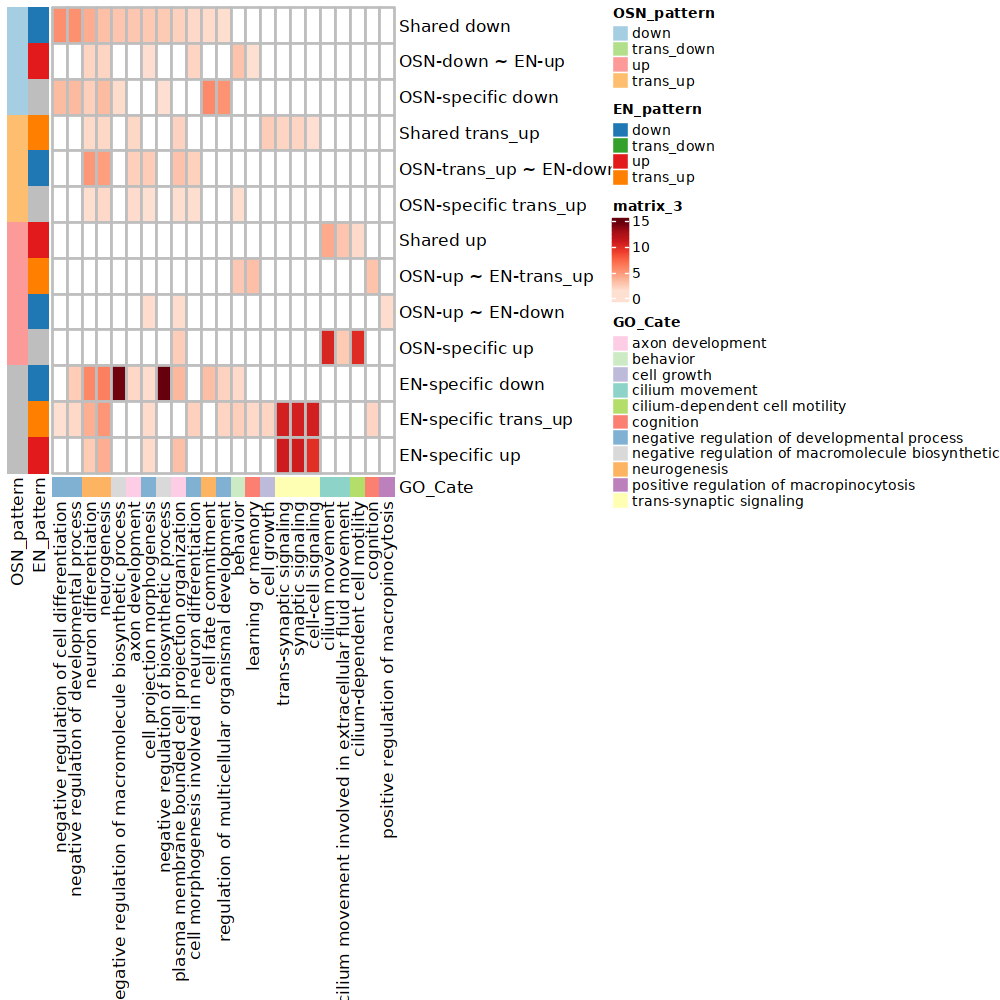

In [31]:
#dpp
ht_list <- Heatmap(
  dpp,
    na_col = "white",
    col                          = colorRamp2(seq(from=min(dpp,na.rm = T),to=max(dpp,na.rm = T),length=8),brewer.pal(9, "Reds")[-1]),
    cluster_columns              = F,
    cluster_rows                 = F,
    show_row_names               = T,
    show_column_names            = T,
    row_names_max_width = unit(15, "cm"),
    column_names_max_height  = unit(15, "cm"),
    show_row_dend = F,
    bottom_annotation = HeatmapAnnotation(
               GO_Cate=pp_sigx_reducedTerms[dpp_fullname,'parentTerm'],
    col=list(GO_Cate=go_color)
    ),
    rect_gp = gpar(col = "grey", lwd = 2),
    left_annotation=rowAnnotation(
        # pattern=rownames(dpp),
        OSN_pattern = trend[rownames(dpp),'OSN'],
        EN_pattern = trend[rownames(dpp),'EN'],
        col = list(OSN_pattern = oe_color,
                  EN_pattern=en_color)
    ),
    #row_split = trend[rownames(dpp),'OSN']
    #row_split = c(rep('OSN down',3), rep('OSN trans_up',2),rep('OSN up',3),rep('EN specifc',3))
)


draw(ht_list, merge_legend = TRUE, heatmap_legend_side = "right", 
     annotation_legend_side = "right")

dev.print(pdf, file='./figures/NC/go_circle2.pdf', height=9, width=14)

In [43]:
write.table(dpp, file='./data/NC/sf12.gobp.txt', sep='\t', quote = F)

# PART2: direct pathway overlap-------------------GOBP level----------------------------------------------------------------------------------------------

#### pathway olf

In [14]:
#library(enrichR)
library(dplyr)

DEG_Olf_bytrend <- split(DEG_trend_Olf$gene,DEG_trend_Olf$trend_class)
DEG_trend_Olf_gobp <- lapply(DEG_Olf_bytrend, function(x) {df <-    gost(x, source='GO:BP', 
                                                                        custom_bg = custom_olfbg,
                                                                         correction_method = "fdr",
                                                                         #evcodes = TRUE,
                                                                         user_threshold=0.1,significant=F)$result %>%subset(term_size < 2000)  }) 

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.



In [66]:
#subset(DEG_trend_Olf_gobp$trans_up, grepl('dend',term_name))

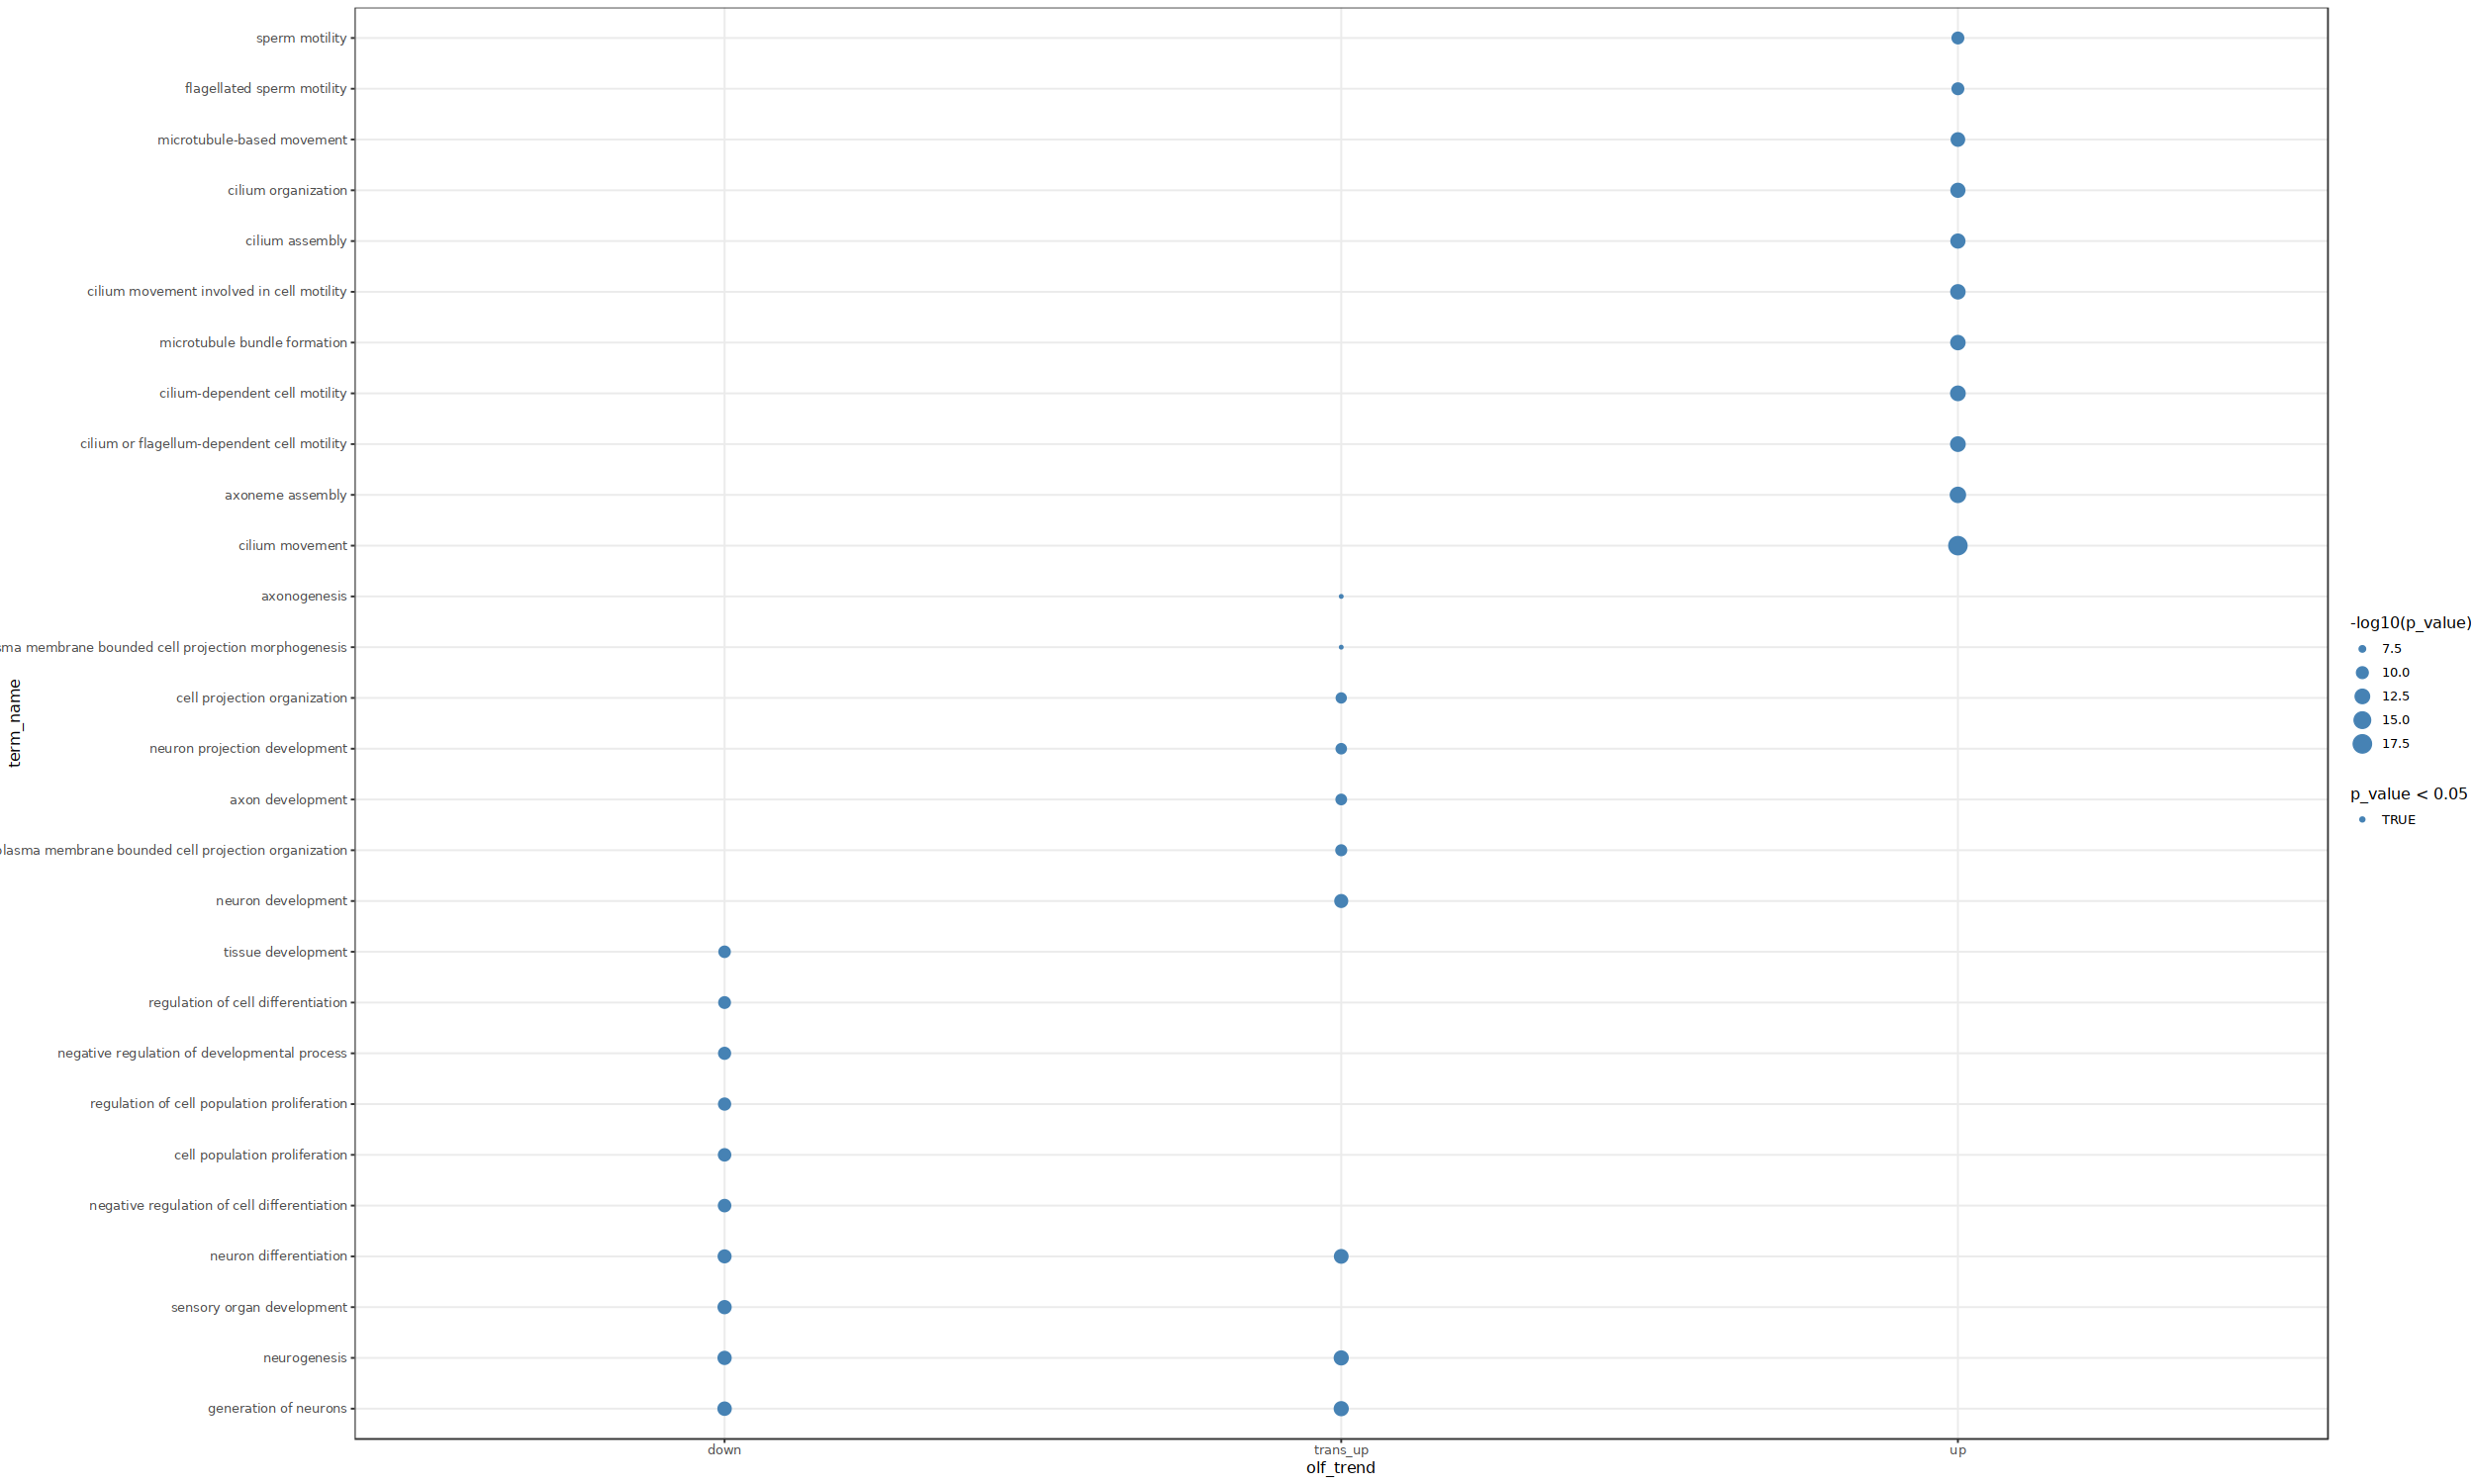

In [15]:
                       
DEG_trend_Olf_gobps <- do.call(rbind,DEG_trend_Olf_gobp)
DEG_trend_Olf_gobps$olf_trend <- str_split(rownames(DEG_trend_Olf_gobps),pattern = '\\.',simplify = T)[,1]
gobps_olf_sig <- subset(DEG_trend_Olf_gobps, p_value < 0.05)

gobps_olf_sig <- gobps_olf_sig%>%group_by(olf_trend)%>%top_n(10, -p_value)
gobps_olf_sig$term_name <- factor(gobps_olf_sig$term_name, levels=unique(gobps_olf_sig$term_name))
#ggplot(gobps_olf_sig, aes(x=olf_trend,y=term_name,size=-log10(p_value)))+geom_point(color='steelblue')+theme_bw()

ggplot(gobps_olf_sig, aes(x=olf_trend,y=term_name,size=-log10(p_value)))+
geom_point(aes(shape=p_value < 0.05),color='steelblue')+theme_bw()

In [68]:
#subset(DEG_trend_Olf_gobps)

#### pathway brain

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.

Detected custom background input, domain scope is set to 'custom'.



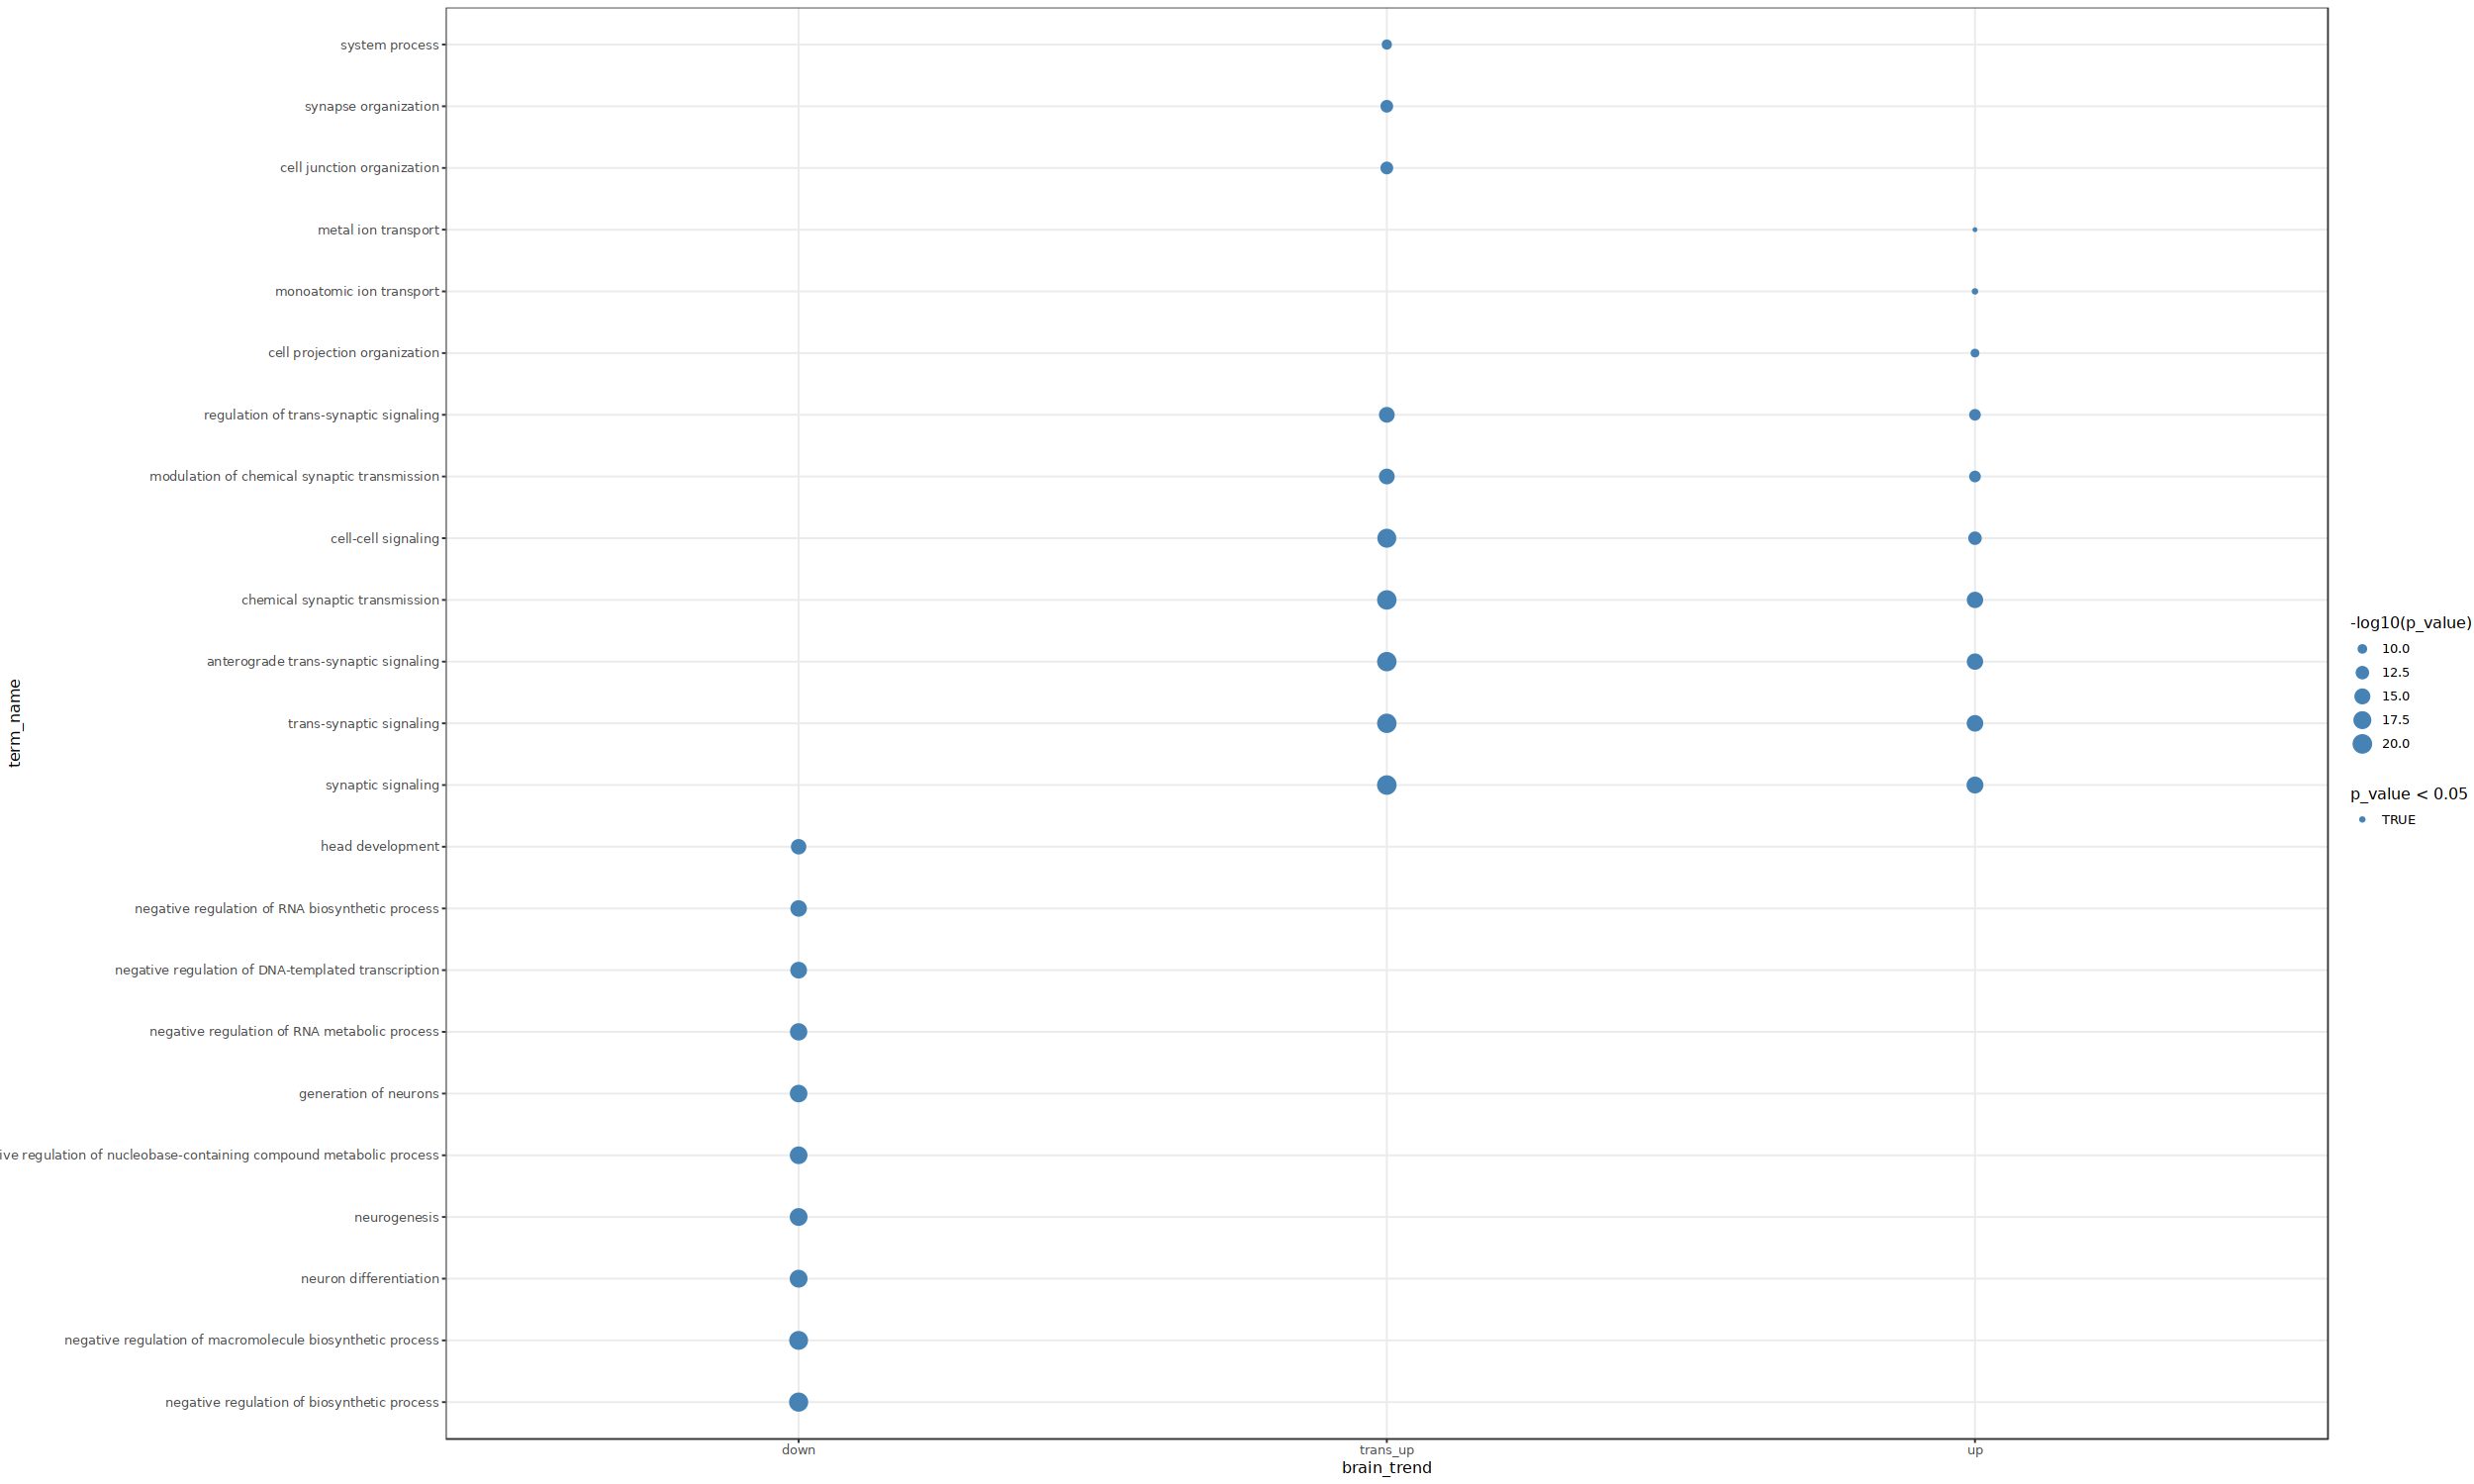

In [16]:
DEG_trend_brain_gobp <- lapply(DEG_trend_Brain, function(x) {df <-    gost(x, source='GO:BP',
                                                                           custom_bg = brain_bg,
                                                                           #evcodes = TRUE, 
                                                                           correction_method = "fdr",user_threshold=0.1,significant=F)$result %>%subset(term_size < 2000)  } )


DEG_trend_brain_gobps <- do.call(rbind,DEG_trend_brain_gobp)
DEG_trend_brain_gobps$brain_trend <- str_split(rownames(DEG_trend_brain_gobps),pattern = '\\.',simplify = T)[,1]
gobps_brain_sig <- subset(DEG_trend_brain_gobps, p_value < 0.05)

gobps_brain_sig <- gobps_brain_sig%>%group_by(brain_trend)%>%top_n(10, -p_value)

gobps_brain_sig$term_name <- factor(gobps_brain_sig$term_name, levels=unique(gobps_brain_sig$term_name))

ggplot(gobps_brain_sig, aes(x=brain_trend,y=term_name,size=-log10(p_value)))+
geom_point(aes(shape=p_value < 0.05),color='steelblue')+theme_bw()



In [17]:


subset(DEG_trend_brain_gobps,term_name=='cell death')
subset(DEG_trend_brain_gobps,term_name=='myelination')
subset(DEG_trend_brain_gobps,term_name=='dendrite development')
subset(DEG_trend_brain_gobps,term_name=='neuron apoptotic process')

subset(DEG_trend_Olf_gobps,term_name=='cell death')
subset(DEG_trend_Olf_gobps,term_name=='myelination')
subset(DEG_trend_Olf_gobps,term_name=='dendrite development')
subset(DEG_trend_Olf_gobps,term_name=='neuron apoptotic process')

# subset(DEG_trend_brain_gobps,grepl('neuron apoptotic process',term_name))
# subset(DEG_trend_Olf_gobps,grepl('neuron apoptotic process',term_name))


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,brain_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.190,query_1,TRUE,4.277755e-06,1777,2906,348,0.1197522,0.19583568,GO:0008219,GO:BP,cell death,19146,3132,GO:0009987,down
up.2007,query_1,FALSE,4.398691e-01,1777,2176,220,0.1011029,0.12380416,GO:0008219,GO:BP,cell death,19146,3132,GO:0009987,up
trans_up.152,query_1,TRUE,4.118265e-04,1777,968,130,0.1342975,0.07315701,GO:0008219,GO:BP,cell death,19146,3132,GO:0009987,trans_up


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,brain_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.3246,query_1,FALSE,0.41871653,149,2906,28,0.009635237,0.18791946,GO:0042552,GO:BP,myelination,19146,10150,GO:0008366,down
up.209,query_1,TRUE,0.01182981,149,2176,32,0.014705882,0.21476510,GO:0042552,GO:BP,myelination,19146,10150,GO:0008366,up
trans_up.3264,query_1,FALSE,0.46809623,149,968,10,0.010330579,0.06711409,GO:0042552,GO:BP,myelination,19146,10150,GO:0008366,trans_up


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,brain_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.504,query_1,TRUE,0.0086882960,233,2906,55,0.01892636,0.2360515,GO:0016358,GO:BP,dendrite development,19146,5195,GO:00311....,down
up.272,query_1,TRUE,0.0297434954,233,2176,43,0.01976103,0.1845494,GO:0016358,GO:BP,dendrite development,19146,5195,GO:00311....,up
trans_up.169,query_1,TRUE,0.0007884943,233,968,28,0.02892562,0.1201717,GO:0016358,GO:BP,dendrite development,19146,5195,GO:00311....,trans_up


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,brain_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.762,query_1,TRUE,0.03856628,274,2906,59,0.02030282,0.21532847,GO:0051402,GO:BP,neuron apoptotic process,19146,13509,GO:0006915,down
up.2675,query_1,FALSE,0.50756547,274,2176,37,0.01700368,0.13503650,GO:0051402,GO:BP,neuron apoptotic process,19146,13509,GO:0006915,up
trans_up.395,query_1,TRUE,0.02722850,274,968,26,0.02685950,0.09489051,GO:0051402,GO:BP,neuron apoptotic process,19146,13509,GO:0006915,trans_up


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,olf_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.410,query_1,TRUE,0.01617238,1647,673,97,0.1441308,0.05889496,GO:0008219,GO:BP,cell death,15491,3132,GO:0009987,down
trans_up.489,query_1,FALSE,0.16093707,1647,486,67,0.1378601,0.04068002,GO:0008219,GO:BP,cell death,15491,3132,GO:0009987,trans_up
up.1257,query_1,FALSE,0.52605259,1647,852,102,0.1197183,0.06193078,GO:0008219,GO:BP,cell death,15491,3132,GO:0009987,up


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,olf_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.4765,query_1,FALSE,0.7199778,138,673,6,0.008915305,0.04347826,GO:0042552,GO:BP,myelination,15491,10150,GO:0008366,down
trans_up.440,query_1,FALSE,0.1338681,138,486,10,0.020576132,0.07246377,GO:0042552,GO:BP,myelination,15491,10150,GO:0008366,trans_up
up.1393,query_1,FALSE,0.5910288,138,852,11,0.012910798,0.07971014,GO:0042552,GO:BP,myelination,15491,10150,GO:0008366,up


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,olf_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.597,query_1,TRUE,0.0500535040,227,673,19,0.02823180,0.08370044,GO:0016358,GO:BP,dendrite development,15491,5195,GO:00311....,down
trans_up.65,query_1,TRUE,0.0007794282,227,486,21,0.04320988,0.09251101,GO:0016358,GO:BP,dendrite development,15491,5195,GO:00311....,trans_up
up.921,query_1,FALSE,0.5092078118,227,852,18,0.02112676,0.07929515,GO:0016358,GO:BP,dendrite development,15491,5195,GO:00311....,up


,query,significant,p_value,term_size,query_size,intersection_size,precision,recall,term_id,source,term_name,effective_domain_size,source_order,parents,olf_trend
,<chr>,<lgl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<list>,<chr>
down.2044,query_1,FALSE,0.34183536,247,673,15,0.02228826,0.06072874,GO:0051402,GO:BP,neuron apoptotic process,15491,13509,GO:0006915,down
trans_up.232,query_1,TRUE,0.04544676,247,486,17,0.03497942,0.06882591,GO:0051402,GO:BP,neuron apoptotic process,15491,13509,GO:0006915,trans_up
up.92,query_1,TRUE,0.07681055,247,852,26,0.03051643,0.10526316,GO:0051402,GO:BP,neuron apoptotic process,15491,13509,GO:0006915,up


[1] "olf"      "trans_up"


preparing gene to GO mapping data...

preparing IC data...

Warning message in calculateSimMatrix(go_analysis$term_id, orgdb = "org.Hs.eg.db", :
“Removed 1 terms that were not found in orgdb for BP”
'select()' returned 1:many mapping between keys and columns



[1] "brain"    "trans_up"


preparing gene to GO mapping data...

preparing IC data...

Warning message in calculateSimMatrix(go_analysis$term_id, orgdb = "org.Hs.eg.db", :
“Removed 1 terms that were not found in orgdb for BP”
'select()' returned 1:many mapping between keys and columns



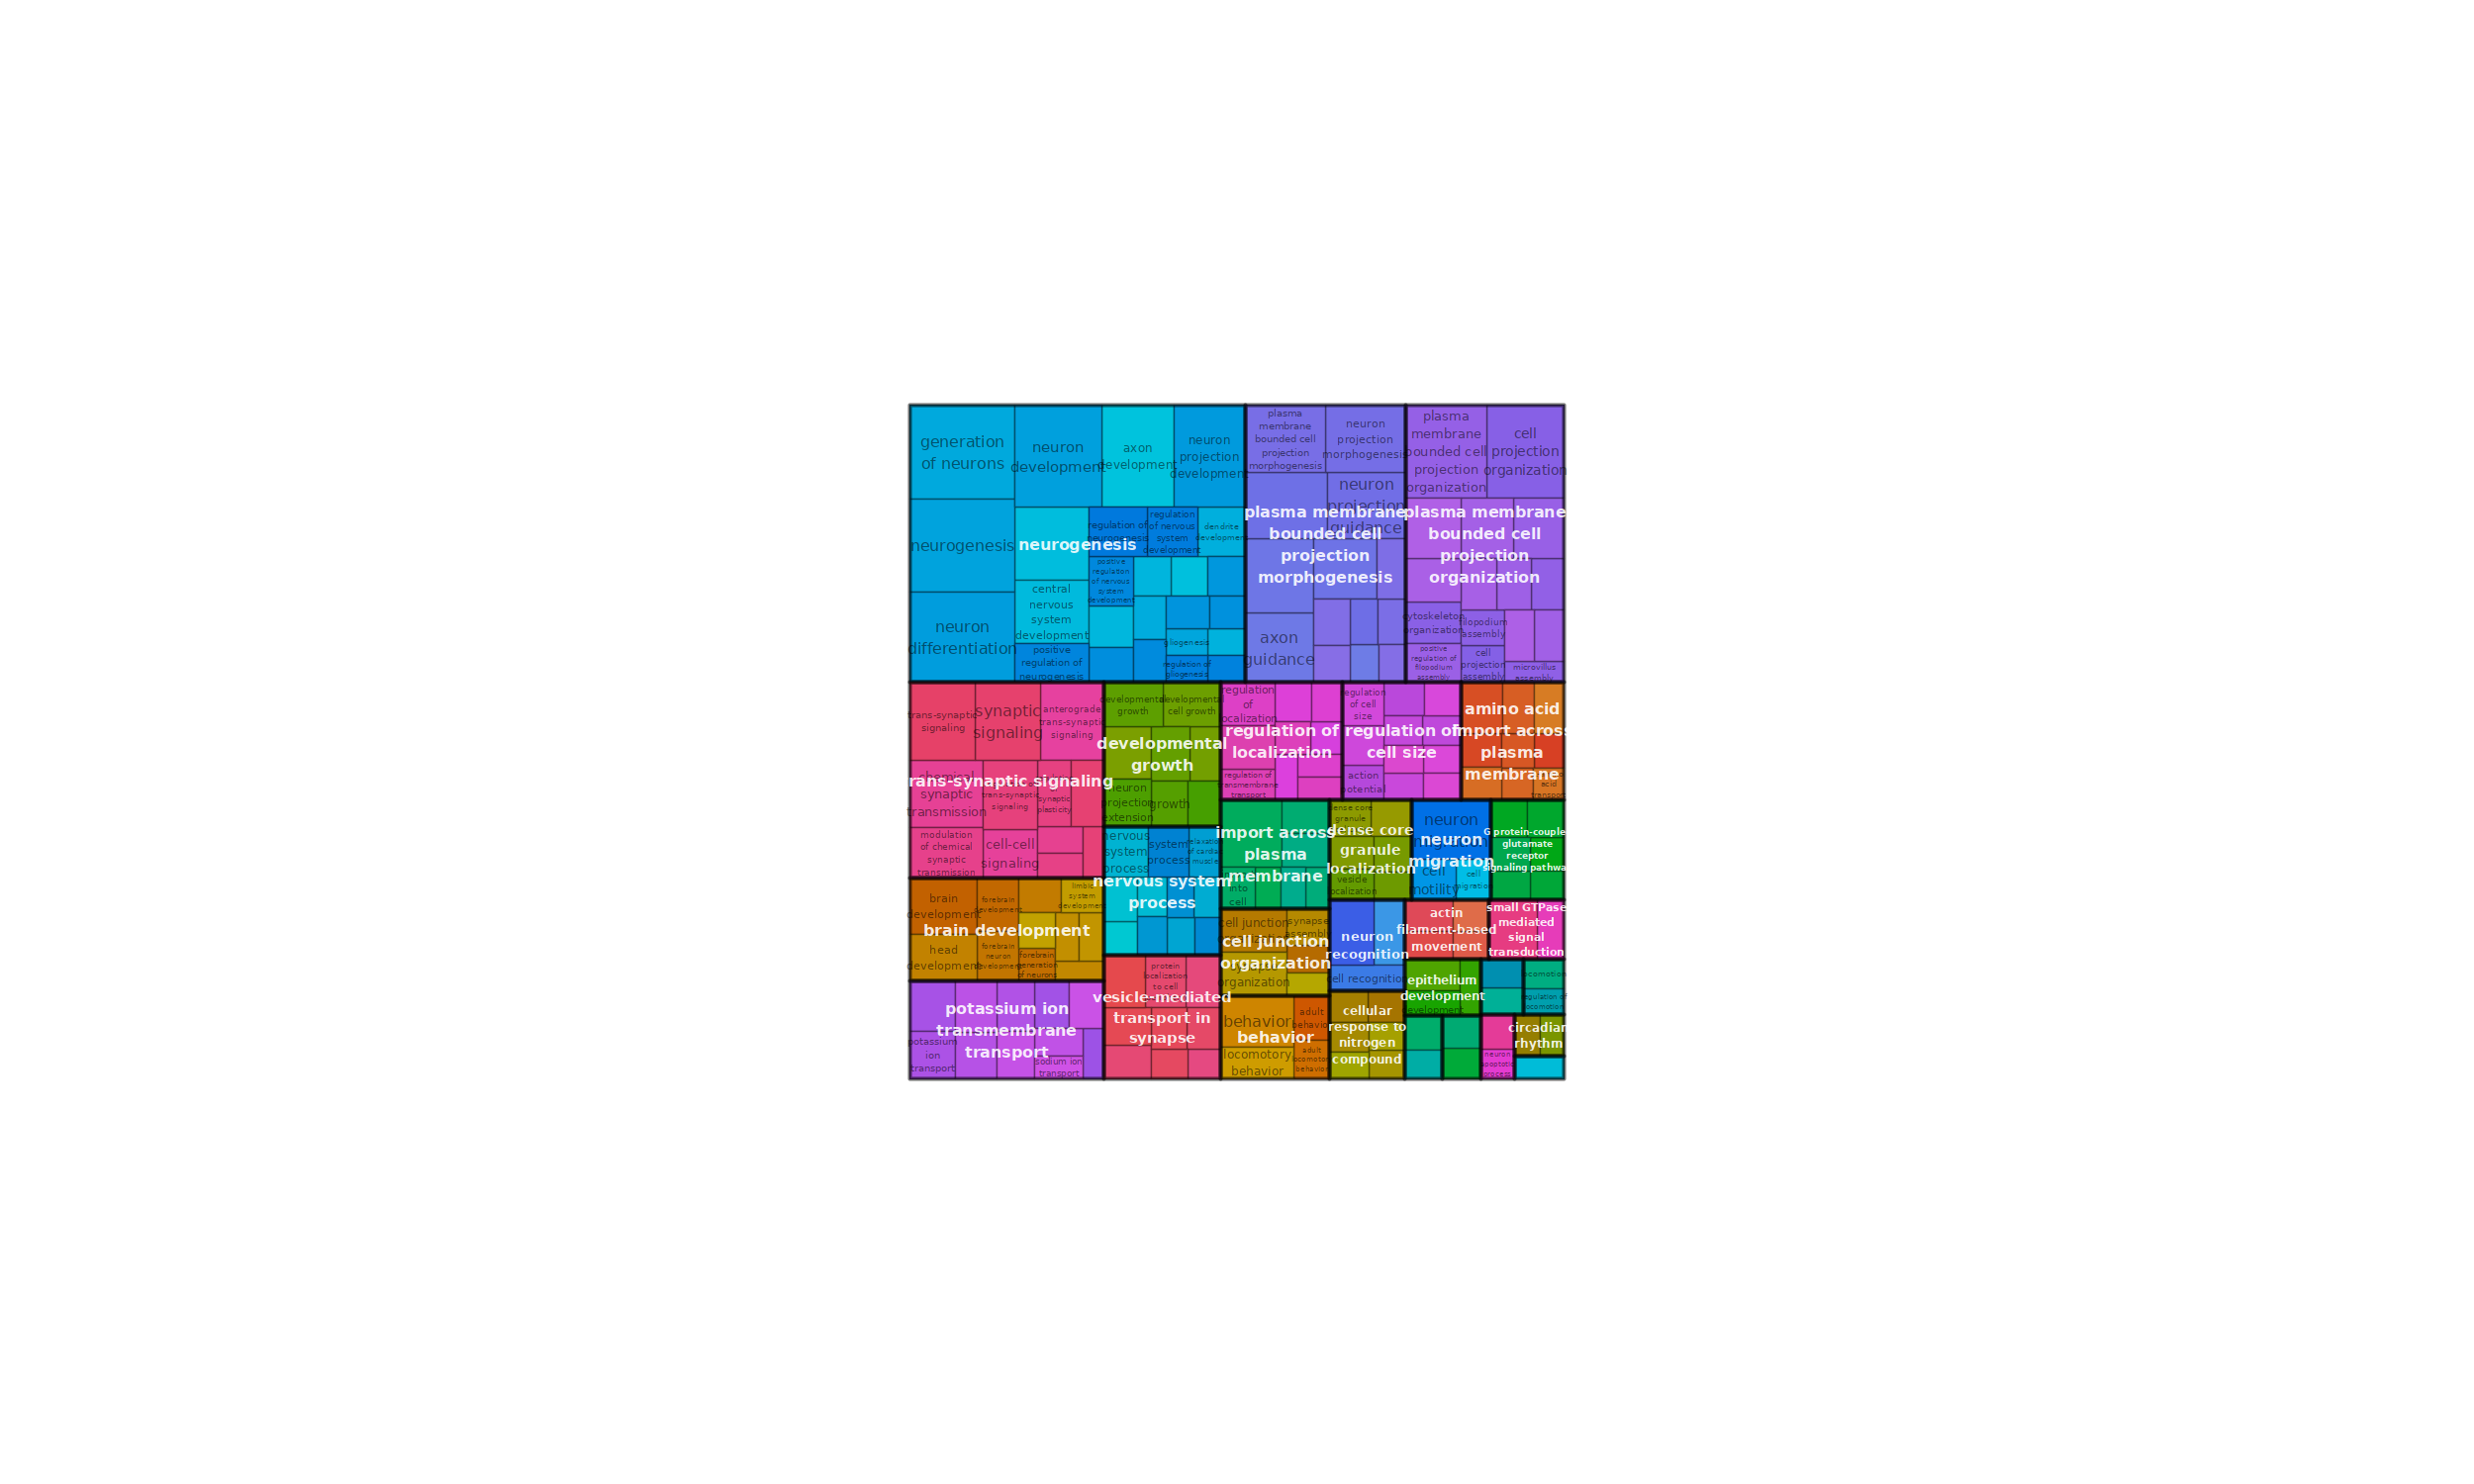

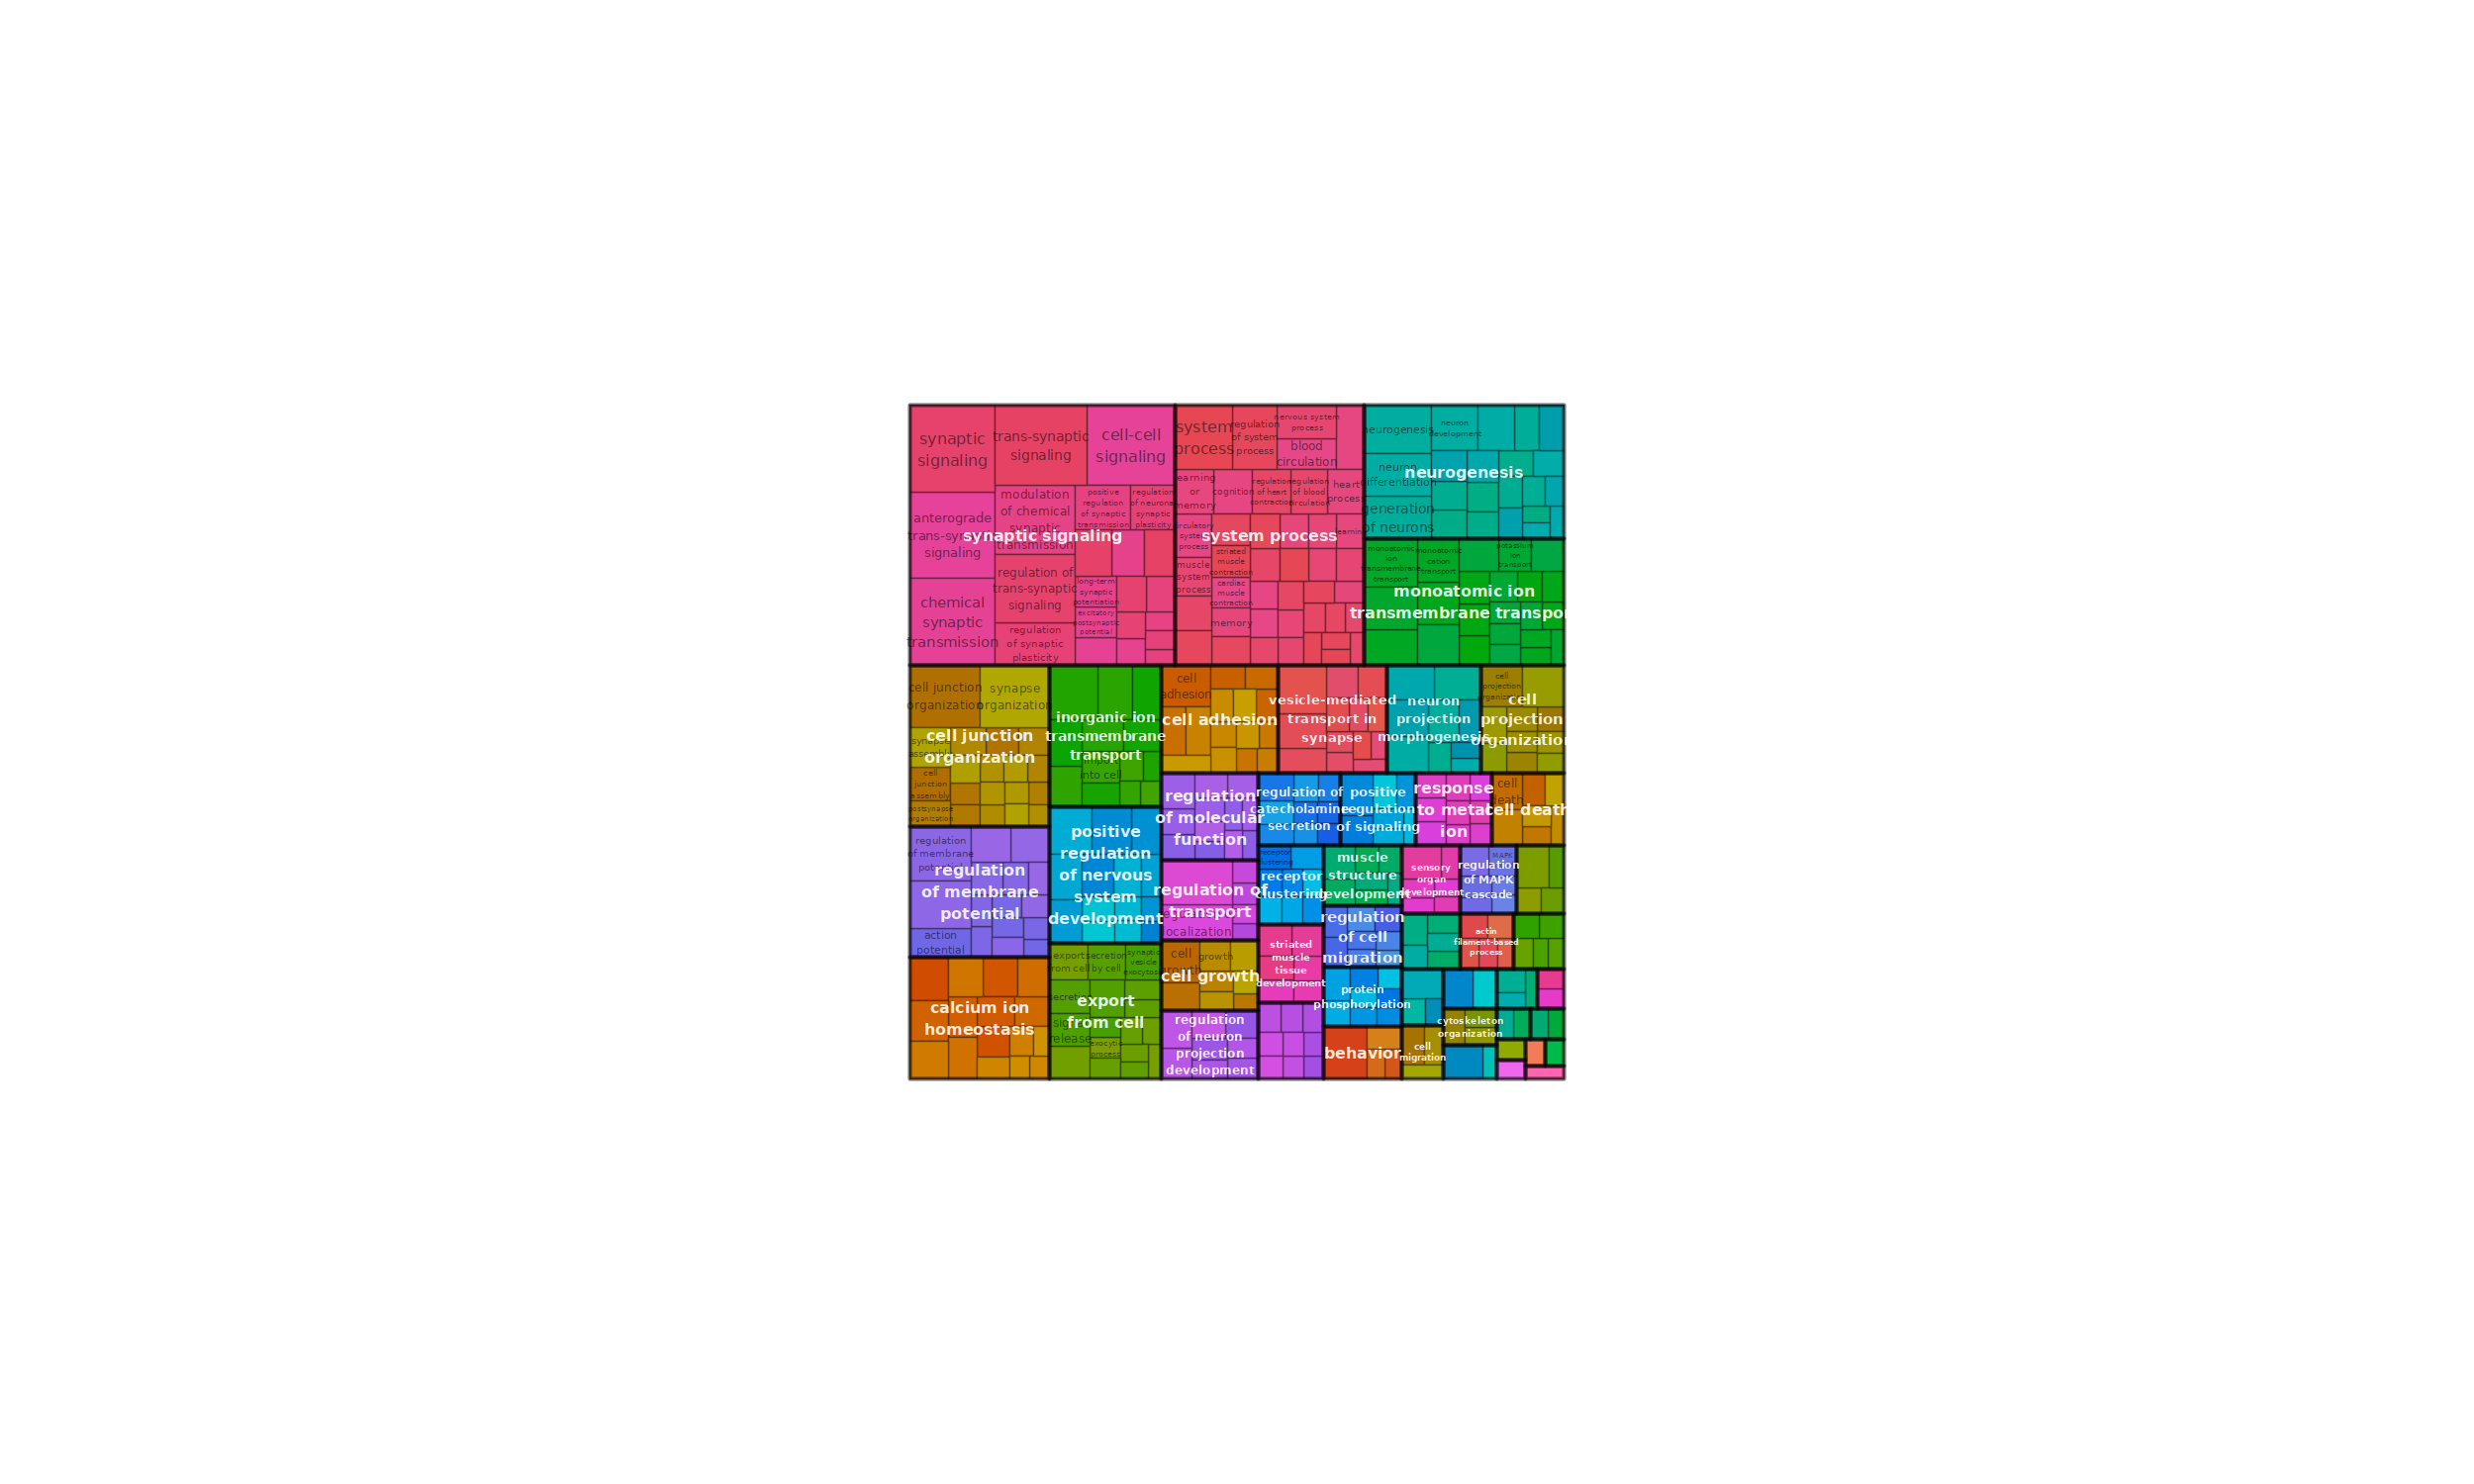

In [18]:

library(rrvgo)

get_bp_enrichr_reducedTerms <- function(trend,overlap,go_analysis){
  #go_analysis$GOID <- str_split(go_analysis$Term,'\\(|\\)',simplify = T)[,2]
  simMatrix <- calculateSimMatrix(go_analysis$term_id,
                                  orgdb="org.Hs.eg.db",
                                  ont="BP",
                                  method="Rel")
  
  
  scores <- setNames(-log10(as.numeric(go_analysis$p_value)), go_analysis$term_id)
  reducedTerms <- reduceSimMatrix(simMatrix,
                                  scores,
                                  orgdb="org.Hs.eg.db")
  
  treemapPlot(reducedTerms)
  
}


go_terms_genelevel <- c()
for(trend in c('trans_up')){#,'trans_up','trans_down'
    
  for (overlp in c('olf','brain')){

    
   # if(overlp=='overlap'){GO_analysis=subset(gobps_devDEG, p_value < 0.05 & olf_trend==trend & brain_trend==trend); print(c(overlp,trend  ))}
    if(overlp=='olf'){GO_analysis=subset(DEG_trend_Olf_gobps, p_value < 0.05 & olf_trend==trend );  print(c(overlp,trend  ))}
    if(overlp=='brain'){GO_analysis=subset(DEG_trend_brain_gobps, p_value < 0.05 & brain_trend==trend);  print(c(overlp,trend  ))}
    go_term <- c()
    if(nrow(GO_analysis) >=5 ){
            go_term <- get_bp_enrichr_reducedTerms(trend,overlp,GO_analysis)
    }

  }
}



In [19]:
library(ggrepel)
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)

#DEG_trend_Brain
get_bp_enrichr_reducedTerms <- function(go_analysis){
  #go_analysis$GOID <- str_split(go_analysis$Term,'\\(|\\)',simplify = T)[,2]
  simMatrix <- calculateSimMatrix(go_analysis$term_id,
                                  orgdb="org.Hs.eg.db",
                                  ont="BP",
                                  method="Rel")
  
  
  scores <- setNames(-log10(as.numeric(go_analysis$p_value.x)), go_analysis$term_id)
  reducedTerms <- reduceSimMatrix(simMatrix,
                                  scores,
                                  orgdb="org.Hs.eg.db")

  return(reducedTerms)
  
}


getDEG_gobps_top_rrvgo <- function(trend){
    print(trend)
  DEG_gobps <- merge(DEG_trend_Olf_gobps[DEG_trend_Olf_gobps$olf_trend==trend,c('term_id','term_name','olf_trend','p_value')], 
                     DEG_trend_brain_gobps[DEG_trend_brain_gobps$brain_trend==trend,c('term_id','term_name','brain_trend','p_value')],
                     by=c('term_id','term_name'))#, all.x=T, all.y=T
  
  DEG_gobps_top <- rbind(DEG_gobps%>%top_n(10, -p_value.x), 
                         DEG_gobps%>%top_n(10, -p_value.y),#,'dendrite development'
                         subset(DEG_gobps,term_name%in%c('neuron apoptotic process','myelination') & (p_value.x < 0.05|p_value.y < 0.05)))
  DEG_gobps_top <- rbind(DEG_gobps_top[!duplicated(DEG_gobps_top$term_id),])


  
  top_rrvgo <- get_bp_enrichr_reducedTerms(DEG_gobps_top)
  
  
  DEG_gobps_top_rrvgo <- merge(DEG_gobps_top, top_rrvgo[,c('go','parentTerm')], by.x='term_id',by.y='go')
  return(DEG_gobps_top_rrvgo)
}


options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)

DEG_gobps_top_rrvgo_down <- getDEG_gobps_top_rrvgo('down')%>%mutate(term=ifelse(term_name==parentTerm, term_name, ''))
DEG_gobps_top_rrvgo_up <- getDEG_gobps_top_rrvgo('up')%>%mutate(term=ifelse(term_name==parentTerm, term_name, ''))
DEG_gobps_top_rrvgo_transup <- getDEG_gobps_top_rrvgo('trans_up')%>%mutate(term=ifelse(term_name==parentTerm, term_name, ''))
#DEG_gobps_top_rrvgo_transdown <- getDEG_gobps_top_rrvgo('trans_down')%>%mutate(term=ifelse(term_name==parentTerm, term_name, ''))


Warning message:
“package ‘ggrepel’ was built under R version 4.3.2”


[1] "down"


preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns



[1] "up"


preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns



[1] "trans_up"


preparing gene to GO mapping data...

preparing IC data...

'select()' returned 1:many mapping between keys and columns



In [73]:
getwd()

[1] "/sc/arion/projects/roussp01a/liting/Olf"

In [20]:
library(RColorBrewer)
set1_colors <- brewer.pal(n = 8, name = "Dark2")[-8]
set3_colors <- brewer.pal(n = 8, name = "Accent")[-4]
set2_colors <- brewer.pal(n = 8, name = "Set1")[-6]
c25 <- c(set1_colors,set2_colors, set3_colors)


parent_t <- unique(rbind(DEG_gobps_top_rrvgo_down,DEG_gobps_top_rrvgo_up, DEG_gobps_top_rrvgo_transup)$parentTerm)
parent_c <- c25[1:length(parent_t)]
names(parent_c) <- parent_t

color_values <- setNames((parent_c), (parent_t))


Warning message:
“Width not defined
ℹ Set with `position_dodge(width = ...)`”


pdf 
  2

Warning message:
“Width not defined
ℹ Set with `position_dodge(width = ...)`”


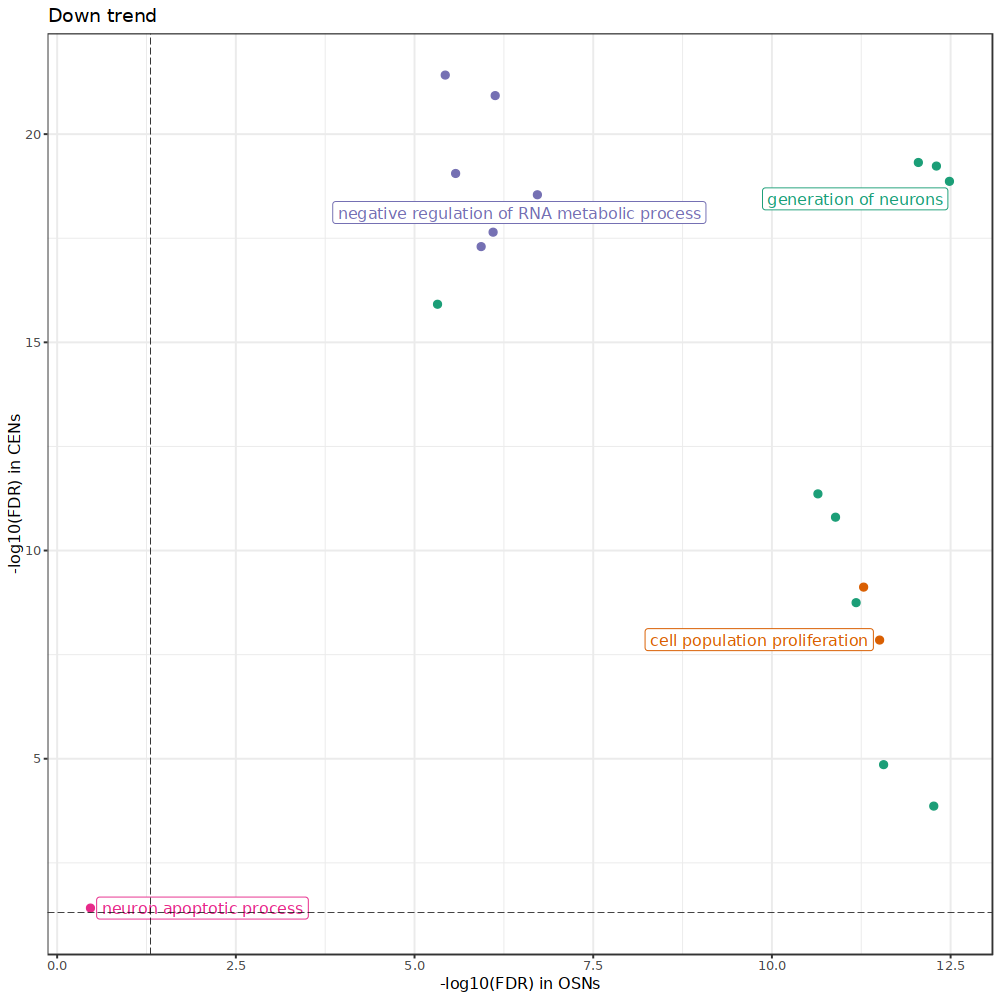

pdf 
  2

Warning message:
“Width not defined
ℹ Set with `position_dodge(width = ...)`”


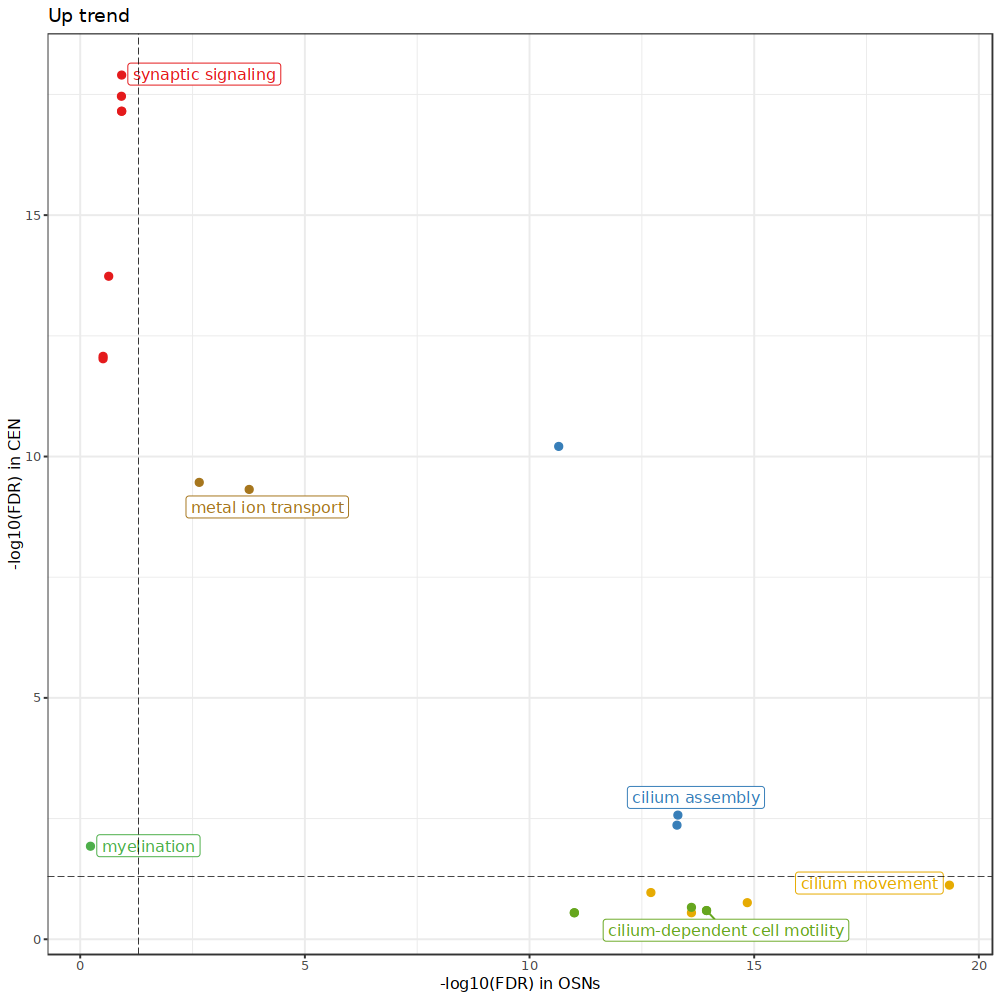

pdf 
  2

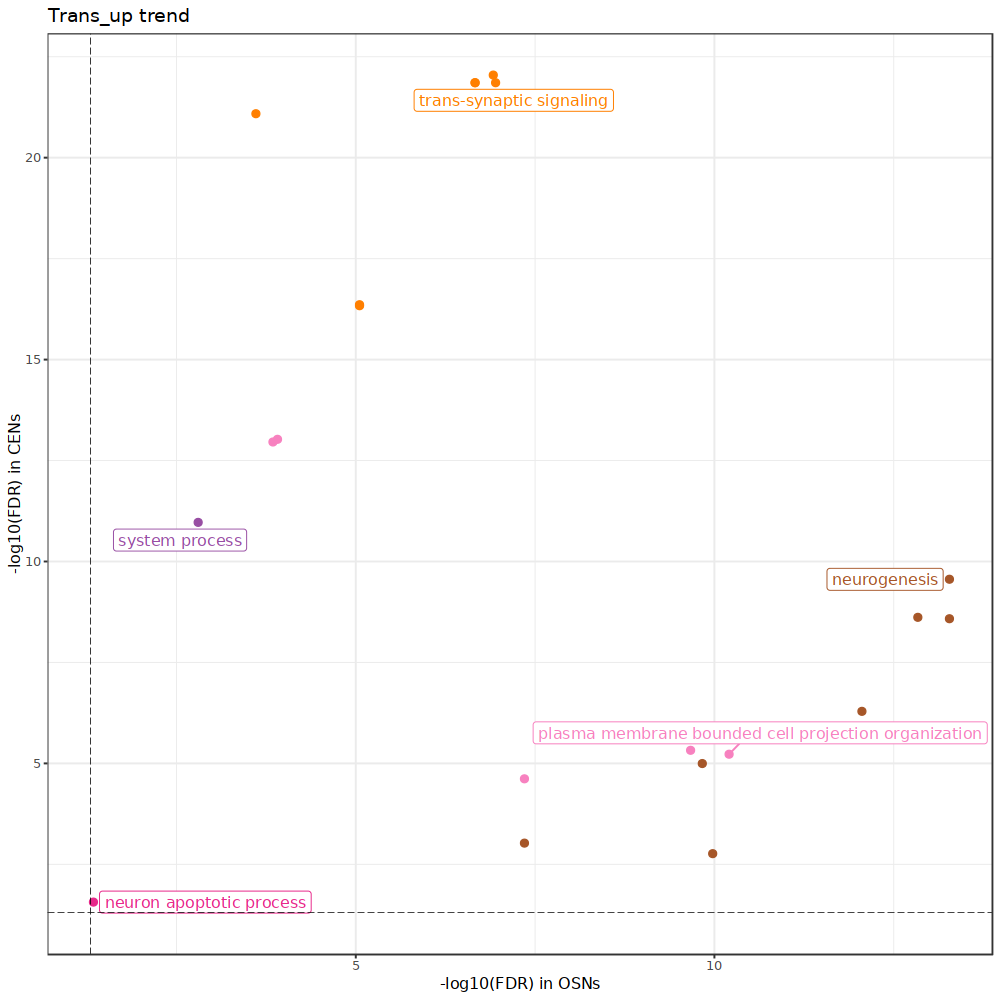

In [40]:

options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
ggplot(DEG_gobps_top_rrvgo_down,aes(x=-log10(p_value.x),y=-log10(p_value.y),color=parentTerm) )+geom_point(size=2)+
 #geom_label_repel(aes(label=term_name),position = "dodge")+
  geom_label_repel(aes(label=term),position = "dodge", max.overlaps=30)+
  geom_vline(xintercept = -log10(0.05), linetype = "longdash", lwd=0.2)+
  geom_hline(yintercept = -log10(0.05),linetype = "longdash", lwd=0.2)+
  theme_bw()+xlab('-log10(FDR) in OSNs')+ylab('-log10(FDR) in CENs')+ggtitle('Down trend')+
theme(legend.position='')+
#scale_color_brewer(palette = "Dark2")#+
#geom_smooth(method = "loess", color = "blue") 
scale_color_manual(values = color_values)

dev.print(pdf, file='./figures/NC/DEG_gobps_top_rrvgo_down.pdf',width=4, height=4)

ggplot(DEG_gobps_top_rrvgo_up, aes(x=-log10(p_value.x),y=-log10(p_value.y),color=parentTerm) )+geom_point(size=2)+
 #geom_label_repel(aes(label=term_name),position = "dodge")+ 
  geom_label_repel(aes(label=term),position = "dodge", max.overlaps=30)+
  geom_vline(xintercept = -log10(0.05), linetype = "longdash", lwd=0.2)+
  geom_hline(yintercept = -log10(0.05),linetype = "longdash", lwd=0.2)+
  theme_bw()+xlab('-log10(FDR) in OSNs')+ylab('-log10(FDR) in CEN')+ggtitle('Up trend')+
theme(legend.position='')+
#scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = color_values)
dev.print(pdf, file='./figures/NC/DEG_gobps_top_rrvgo_up.pdf',width=4, height=4)


ggplot(DEG_gobps_top_rrvgo_transup, aes(x=-log10(p_value.x),y=-log10(p_value.y),color=parentTerm) )+geom_point(size=2)+
# geom_label_repel(aes(label=term_name),position = "dodge",max.overlaps=20)+ 
 geom_label_repel(aes(label=term),position = "dodge", max.overlaps=30)+
  geom_vline(xintercept = -log10(0.05), linetype = "longdash", lwd=0.2)+
  geom_hline(yintercept = -log10(0.05),linetype = "longdash", lwd=0.2)+
theme(legend.position='')+
  theme_bw()+xlab('-log10(FDR) in OSNs') + ylab('-log10(FDR) in CENs') + ggtitle('Trans_up trend')+
theme(legend.position='')+
#scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = color_values)
dev.print(pdf, file='./figures/NC/DEG_gobps_top_rrvgo_transup.pdf',width=4, height=4)


# ggplot(DEG_gobps_top_rrvgo_transdown,aes(x=-log10(p_value.x),y=-log10(p_value.y),color=parentTerm) )+geom_point(size=4)+
#  # geom_label_repel(aes(label=term_name),position = "dodge")+ for each term
#   geom_label_repel(aes(label=term),position = "dodge")+
#   geom_vline(xintercept = -log10(0.05), linetype = "longdash", lwd=0.2)+
#   geom_hline(yintercept = -log10(0.05),linetype = "longdash", lwd=0.2)+
#   theme_bw()

In [46]:
write.table(DEG_gobps_top_rrvgo_transup, file='./data/NC/f3e_DEG_gobps_top_rrvgo_transup.txt', sep='\t', quote=F)
write.table(DEG_gobps_top_rrvgo_up, file='./data/NC/f3f_DEG_gobps_top_rrvgo_up.txt', sep='\t', quote=F)
write.table(DEG_gobps_top_rrvgo_down, file='./data/NC/f3d_DEG_gobps_top_rrvgo_down.txt', sep='\t', quote=F)

Warning message:
“Width not defined
ℹ Set with `position_dodge(width = ...)`”
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


pdf 
  2

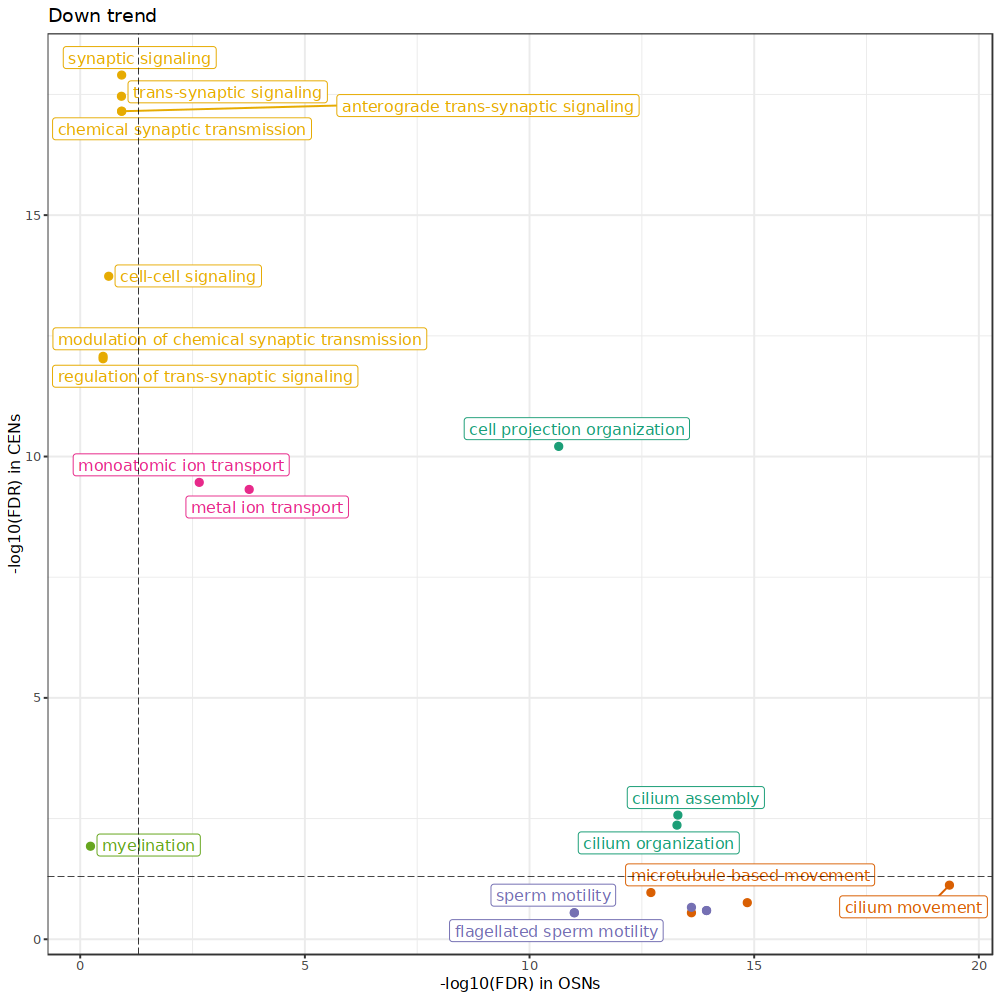

In [34]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
ggplot(DEG_gobps_top_rrvgo_up,aes(x=-log10(p_value.x),y=-log10(p_value.y),color=parentTerm) )+geom_point(size=2)+
 geom_label_repel(aes(label=term_name),position = "dodge")+
  #geom_label_repel(aes(label=term),position = "dodge", max.overlaps=30)+
  geom_vline(xintercept = -log10(0.05), linetype = "longdash", lwd=0.2)+
  geom_hline(yintercept = -log10(0.05),linetype = "longdash", lwd=0.2)+
  theme_bw()+xlab('-log10(FDR) in OSNs')+ylab('-log10(FDR) in CENs')+ggtitle('Down trend')+
theme(legend.position='')+
scale_color_brewer(palette = "Dark2")#+
#geom_smooth(method = "loess", color = "blue") 
#scale_color_manual(values = color_values)

dev.print(pdf, file='./figures/NC/DEG_gobps_all_rrvgo_up.pdf',width=8, height=8)



Warning message:
“Width not defined
ℹ Set with `position_dodge(width = ...)`”


pdf 
  2

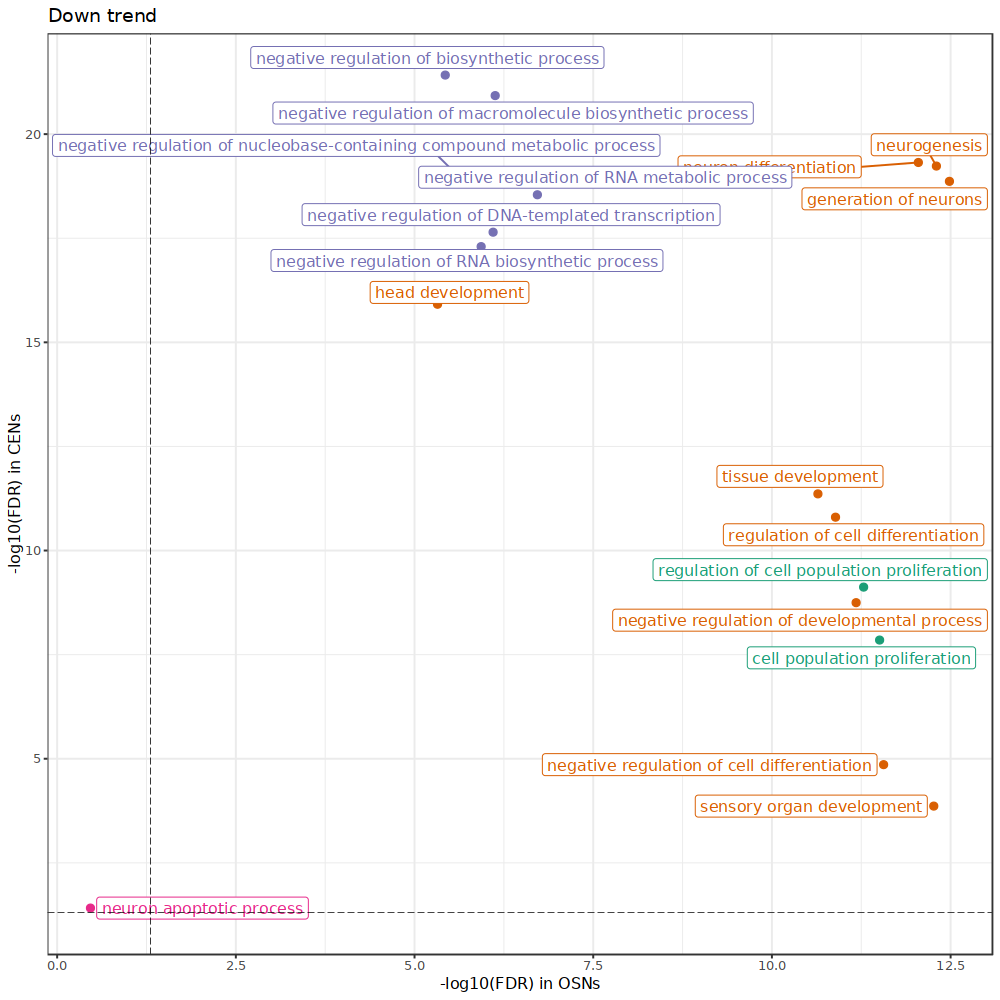

In [37]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
ggplot(DEG_gobps_top_rrvgo_down,aes(x=-log10(p_value.x),y=-log10(p_value.y),color=parentTerm) )+geom_point(size=2)+
 geom_label_repel(aes(label=term_name),position = "dodge")+
  #geom_label_repel(aes(label=term),position = "dodge", max.overlaps=30)+
  geom_vline(xintercept = -log10(0.05), linetype = "longdash", lwd=0.2)+
  geom_hline(yintercept = -log10(0.05),linetype = "longdash", lwd=0.2)+
  theme_bw()+xlab('-log10(FDR) in OSNs')+ylab('-log10(FDR) in CENs')+ggtitle('Down trend')+
theme(legend.position='')+
scale_color_brewer(palette = "Dark2")#+
#geom_smooth(method = "loess", color = "blue") 
#scale_color_manual(values = color_values)
dev.print(pdf, file='./figures/NC/DEG_gobps_all_rrvgo_down.pdf',width=8, height=8)



Warning message:
“Width not defined
ℹ Set with `position_dodge(width = ...)`”


pdf 
  2

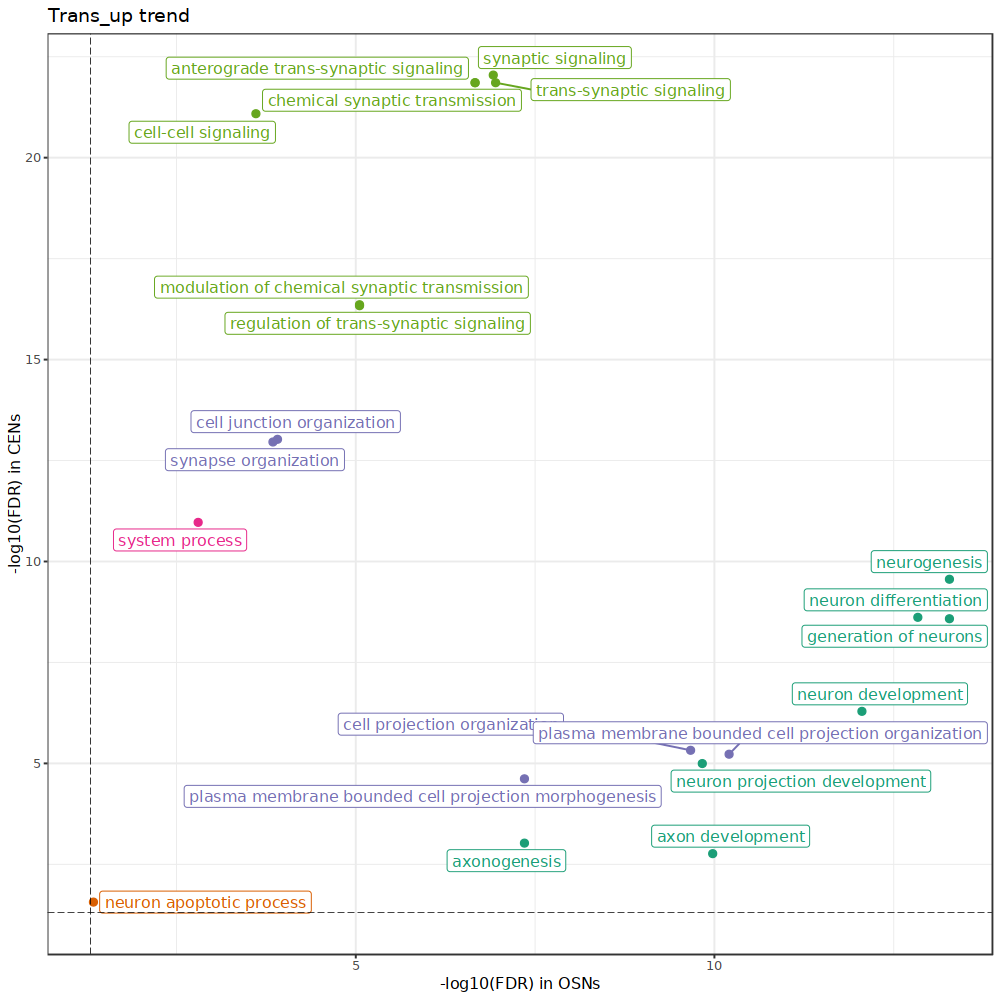

In [39]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
ggplot(DEG_gobps_top_rrvgo_transup,aes(x=-log10(p_value.x),y=-log10(p_value.y),color=parentTerm) )+geom_point(size=2)+
 geom_label_repel(aes(label=term_name),position = "dodge")+
  #geom_label_repel(aes(label=term),position = "dodge", max.overlaps=30)+
  geom_vline(xintercept = -log10(0.05), linetype = "longdash", lwd=0.2)+
  geom_hline(yintercept = -log10(0.05),linetype = "longdash", lwd=0.2)+
  theme_bw()+xlab('-log10(FDR) in OSNs')+ylab('-log10(FDR) in CENs')+ggtitle('Trans_up trend')+
theme(legend.position='')+
scale_color_brewer(palette = "Dark2")#+
#geom_smooth(method = "loess", color = "blue") 
#scale_color_manual(values = color_values)
dev.print(pdf, file='./figures/NC/DEG_gobps_all_rrvgo_transup.pdf',width=8, height=8)

